In [1]:
import cftime
import pandas as pd
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

from scipy.ndimage import label
from pathlib import Path

In [2]:
# Open MEAN_BASELINE.zarr file

# foe every amoc state and every ensemble member open the corresponding net CDF file then compair its ET_os values of every year and date time to that of the historical baseline.

# First we need to calculate when a thristwave happens: a three or more day period of ET_os values above the mean 90th percentile. 

# Once we have determined when a thirstwave occurs for each gridcell along within the definded CONUS bounds, take not of the duration of this event and the difference of the ET_os value from the 90th percentile. 

# Finnaly we will need to calculate the frequency of which these thistwaves occur on a yearly period. So, thistwave stats should be stored based on ensemble member: lat/lon: year: day of year: 

# I want all of this data stored in a ZARR file. With that said I want three values stored, the Freqency of thirstwaves for every year and every member. Then I want the intencity and duration for every year and day of which the thristwave occured. Then with these values I should be able to calculate the avg intencity,, freqeuncy, and duration for every gridcell and plot it. 

# Compair baseline to past file then compair to ftr file in same setup thing

In [4]:
# Open the baseline file 
baseline = xr.open_zarr(
    "/data1/michsh/90th_zarr/HIST_BASELINE.zarr"
)

daily_ds_hist = xr.open_zarr(
    "/data1/michsh/combined_thirstwave/HIST_tw_metrics.zarr"
)

daily_ds_ftr = xr.open_zarr(
    "/data1/michsh/combined_thirstwave/FTR_tw_metrics.zarr"
)

print(daily_ds_ftr)

input_data_paths = [daily_ds_hist, daily_ds_ftr]

# Define desired AMOC state and member
AMOC_state = ['1281']
ensemble_members = ['001']

w_lon = -103
e_lon = -89
n_let = 46
s_lat = 39

# Every Ensemble member take midwest AVG and then find 90th percentile for every AVG region. 


<xarray.Dataset> Size: 33GB
Dimensions:               (AMOC: 4, member: 20, time: 18404, lat: 30, lon: 47,
                           year: 86)
Coordinates:
  * AMOC                  (AMOC) object 32B '1231' '1251' '1281' '1301'
    dayofyear             (time) float64 147kB dask.array<chunksize=(18404,), meta=np.ndarray>
  * lat                   (lat) float64 240B 24.03 24.97 25.92 ... 50.42 51.36
  * lon                   (lon) float64 376B 235.0 236.2 237.5 ... 291.2 292.5
  * member                (member) object 160B '001' '002' '003' ... '019' '020'
  * time                  (time) object 147kB 2015-04-01 00:00:00 ... 2100-10...
  * year                  (year) int64 688B 2015 2016 2017 ... 2098 2099 2100
Data variables:
    ET_os                 (AMOC, member, time, lat, lon) float32 8GB dask.array<chunksize=(1, 1, 18404, 25, 25), meta=np.ndarray>
    actual_tw_ET_os       (AMOC, member, time, lat, lon) float32 8GB dask.array<chunksize=(1, 1, 18404, 25, 25), meta=np.ndarray>
  

--- Processing All Members for Historical Period ---


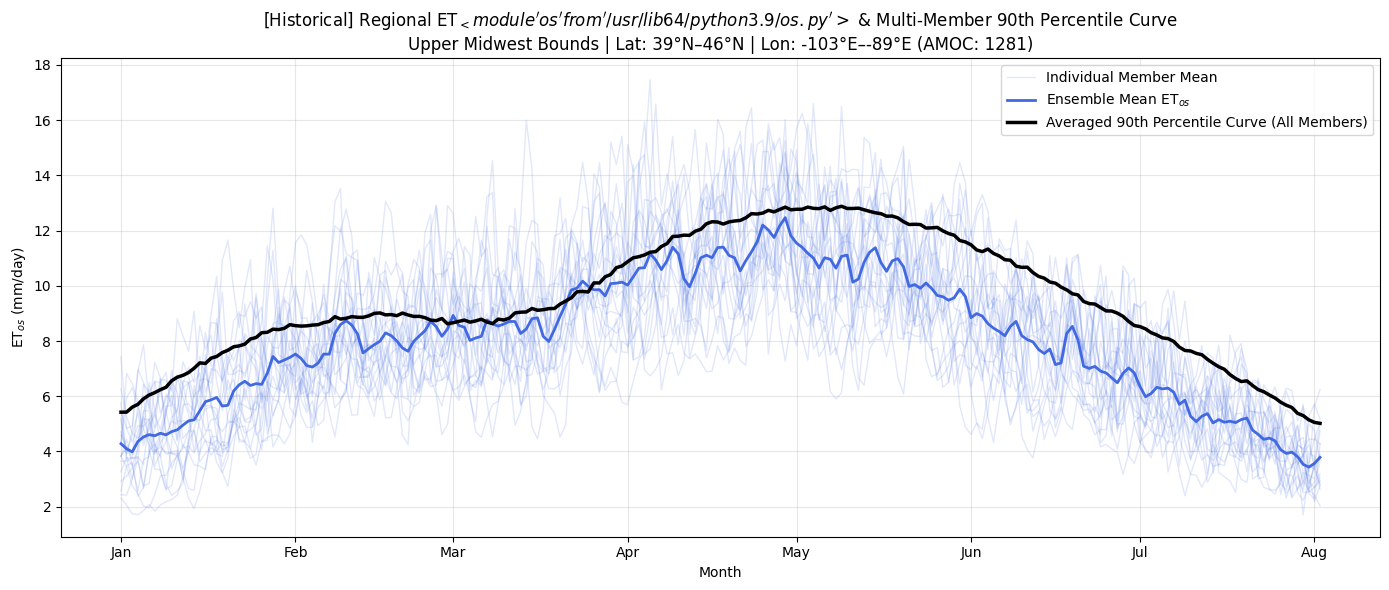

--- Processing All Members for Future Period ---


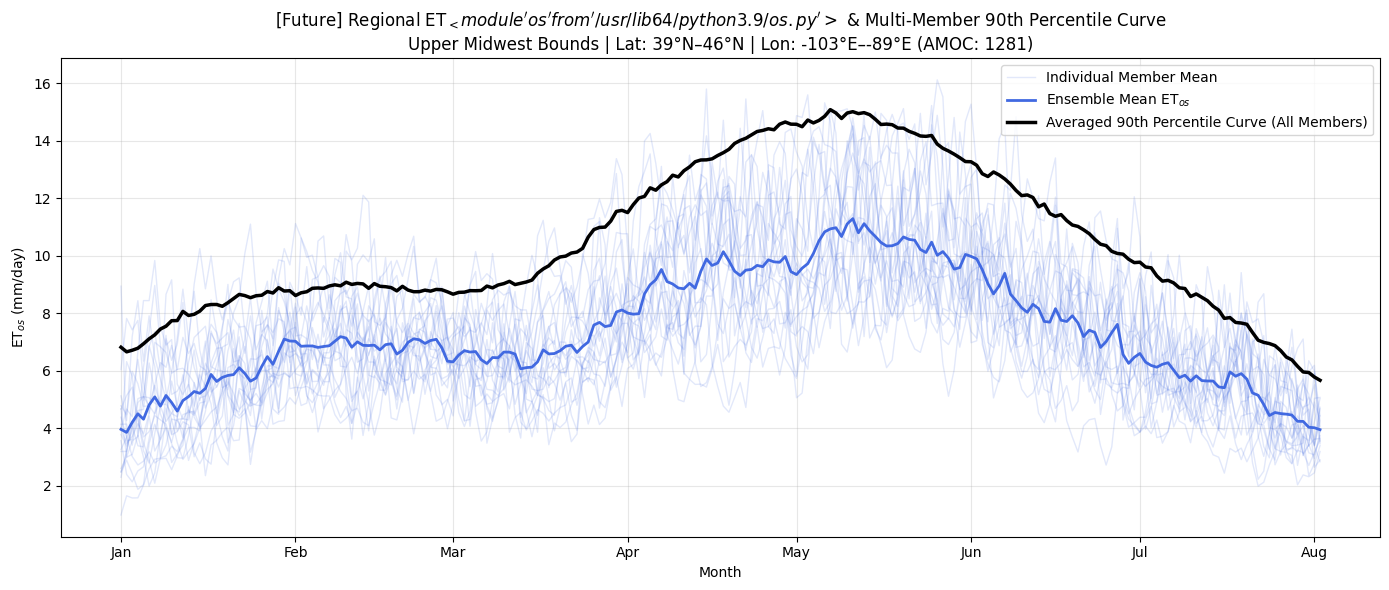

In [29]:
from pathlib import Path
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# ==========================================
# 1. LOAD DATASETS
# ==========================================
baseline = xr.open_zarr("/data1/michsh/90th_zarr/HIST_BASELINE.zarr")
daily_ds_hist = xr.open_zarr(
    "/data1/michsh/combined_thirstwave/HIST_tw_metrics.zarr"
)
daily_ds_ftr = xr.open_zarr(
    "/data1/michsh/combined_thirstwave/FTR_tw_metrics.zarr"
)

# ==========================================
# 2. CONFIGURATION & BOUNDS
# ==========================================
AMOC_state = 1281  # Target AMOC state

# Upper Midwest spatial bounds
w_lon, e_lon, n_lat, s_lat = -103, -89, 46, 39

w_lon_360 = w_lon + 360 if w_lon < 0 else w_lon
e_lon_360 = e_lon + 360 if e_lon < 0 else e_lon

lon_slice = slice(min(w_lon_360, e_lon_360), max(w_lon_360, e_lon_360))
lat_slice = slice(min(s_lat, n_lat), max(s_lat, n_lat))

periods = {"Historical": daily_ds_hist, "Future": daily_ds_ftr}

# ==========================================
# 3. MULTI-MEMBER REGIONAL PROCESSING
# ==========================================
for period_name, ds in periods.items():
    print(f"--- Processing All Members for {period_name} Period ---")

    # Isolate target AMOC state and slice spatially
    try:
        ds_subset = ds.sel(AMOC=AMOC_state, lat=lat_slice, lon=lon_slice)
    except (ValueError, KeyError):
        ds_subset = ds.sel(AMOC=str(AMOC_state), lat=lat_slice, lon=lon_slice)

    # Calculate cosine latitude weights for the grid box size variation
    weights = np.cos(np.deg2rad(ds_subset.lat))
    weights.name = "weights"

    # Compute area-weighted regional mean for ET_os
    weighted_et = ds_subset["ET_os"].weighted(weights)
    member_regional_means = weighted_et.mean(dim=["lat", "lon"])

    # -------------------------------------------------------------
    # FIXED: Rechunk the 'member' dimension into a single chunk
    # -------------------------------------------------------------
    member_regional_means = member_regional_means.chunk({"member": -1})

    # -------------------------------------------------------------
    # CALCULATE THE 90TH PERCENTILE CURVE ACROSS MEMBERS
    # -------------------------------------------------------------
    # Group by day of the year to get a climatological daily threshold
    # then calculate the 90th percentile across the time/member distribution
    thirstwave_90th_curve = member_regional_means.groupby(
        "time.dayofyear"
    ).quantile(0.90, dim=["time", "member"])

    # Map the threshold back to a full year length for visualization
    sample_year = str(member_regional_means.time.dt.year[0].values)
    single_year_data = member_regional_means.sel(time=sample_year)

    # Align the calculated 90th percentile curve with the sample year timeline
    aligned_threshold = thirstwave_90th_curve.sel(
        dayofyear=single_year_data.time.dt.dayofyear
    )

    # ------------------------------------------
    # PLOTTING THE RESULTS
    # ------------------------------------------
    fake_dates = pd.date_range(
        start=f"{sample_year}-01-01", periods=len(single_year_data.time), freq="D"
    )

    plt.figure(figsize=(14, 6))

    # Plot the individual regional timelines for each ensemble member to see spread
    for m in member_regional_means.member.values:
        member_series = member_regional_means.sel(member=m, time=sample_year)
        plt.plot(
            fake_dates,
            member_series,
            color="royalblue",
            alpha=0.15,
            linewidth=1,
            label="Individual Member Mean" if m == member_regional_means.member[0] else "",
        )

    # Plot the ensemble-mean ET_os for that sample year
    ensemble_mean_series = single_year_data.mean(dim="member")
    plt.plot(
        fake_dates,
        ensemble_mean_series,
        color="royalblue",
        linewidth=2,
        label="Ensemble Mean ET$_{os}$",
    )

    # Plot the calculated 90th percentile curve across all members
    plt.plot(
        fake_dates,
        aligned_threshold.values,
        color="black",
        linewidth=2.5,
        linestyle="-",
        label="Averaged 90th Percentile Curve (All Members)",
    )

    # Format Axis
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    plt.xlabel("Month")
    plt.ylabel("ET$_{os}$ (mm/day)")
    plt.title(
        f"[{period_name}] Regional ET$_{os}$ & Multi-Member 90th Percentile Curve\n"
        f"Upper Midwest Bounds | Lat: {s_lat}°N–{n_lat}°N | Lon: {w_lon}°E–{e_lon}°E (AMOC: {AMOC_state})"
    )
    plt.grid(alpha=0.3)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

In [12]:
def hist_tw_values(AMOC_state, ensemble_members, year):
    for state in AMOC_state:
        for member in ensemble_members:

            if int(member) <= 10:
                bmb = 'BHISTcmip6'
            else:
                bmb = 'BHISTsmbb' 

            file_name = f'{bmb}_LE2-{state}.{member}_ETos_daily.nc'

            file_path = Path(f'{input_data_path}/{state}/{member}/{file_name}')

            # Verify the file exists before trying to open it
            if file_path.exists():
                print(f"Opening: {file_name}")
                ds_hist = xr.open_dataset(file_path)
            else:
                print(f"Warning: File not found -> {file_name}")

            ds_hist = ds_hist.sel(time=str(year))

            lon = raw_lon if ds_hist.lon.max() <= 180 else (raw_lon + 360)

            # Point work
            point = ds_hist['ET_os'].sel(lat=lat, lon=lon, method='nearest')

            threshold = baseline['threshold90'].sel(lat=lat, lon=lon, method='nearest')

            point = point.assign_coords(dayofyear=point.time.dt.dayofyear)

            daily_threshold = threshold.sel(dayofyear=point.dayofyear)

            exceedance = point > daily_threshold

            events = []

            start = None
            
            mask = exceedance.values

            for i, above in enumerate(mask):    # Pairs every boolean value (above) with the a day number (i)

                if above and start is None:     # The moment it hits a day that exceeds the threshold (True) and it isn't already tracking an event, it marks that index as the start day
                    start = i

                elif not above and start is not None:   # When it hits a day that falls back below the threshold (False), it stops and calculates the duration

                    duration = i - start 

                    if duration >= 3:
                        events.append((start,i))

                    start = None 

            if start is not None:   # Handle event that ends on last day

                duration = len(mask) - start

                if duration >= 3:
                    events.append((start, len(mask)))

            print(events)

            frequency = len(events)

            print(f"\nFrequency: {frequency}\n")

            for event_num, (start, end) in enumerate(events, start=1):

                event_data = point.isel(time=slice(start, end))
                thr = daily_threshold.isel(time=slice(start, end))

                duration = end - start
                intensity = event_data - thr

                print(f'Thirstwave characteristics {event_num}')
                print(f"ET_os values: {event_data.values}")
                print(f"Threshold values: {thr.values}")
                print(f"Intensity values: {intensity.values}\n")

                # Days that belong to a thirstwave

            thirstwave = np.zeros(len(point), dtype=bool)

            for start, end in events:
                thirstwave[start:end] = True

            plt.figure(figsize=(14,6))

            # Entire ET_os time series
            plt.plot(
                point.time.dt.dayofyear,
                point,
                "--",
                color="royalblue",
                alpha=0.4
            )

            plt.scatter(
                point.time.dt.dayofyear,
                point,
                s=20,
                color="royalblue",
                label="Daily ET$_{os}$"
            )

            # Days above the threshold
            plt.scatter(
                point.time.dt.dayofyear.values[exceedance.values],
                point.values[exceedance.values],
                s=35,
                color="orange",
                label="Above 90th Percentile",
                zorder=3
            )

            # Days belonging to thirstwaves
            plt.scatter(
                point.time.dt.dayofyear.values[thirstwave],
                point.values[thirstwave],
                s=45,
                color="red",
                label="Thirstwave (≥3 Days)",
                zorder=4
            )

            # Historical threshold
            plt.plot(
                daily_threshold.time.dt.dayofyear,
                daily_threshold,
                color="black",
                linewidth=2,
                label="90th Percentile"
            )

            plt.xlabel("Day of Year")
            plt.ylabel("ET$_{os}$ (mm/day)")
            plt.title(f"{year} Thirstwave Detection\nLat={point['lat'].values}, Lon={point['lon'].values}")
            plt.grid(alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()

In [13]:
def ftr_tw_values(AMOC_state, ensemble_members, year):
    for state in AMOC_state:
        for member in ensemble_members:

            if int(member) <= 10:
                bmb = 'BSSP370cmip6'
            else:
                bmb = 'BSSP370smbb' 

            file_name = f'{bmb}_LE2-{state}.{member}_ETos_daily.nc'

            file_path = Path(f'{input_data_path}/{state}/{member}/{file_name}')

            # Verify the file exists before trying to open it
            if file_path.exists():
                print(f"Opening: {file_name}")
                ds_hist = xr.open_dataset(file_path)
            else:
                print(f"Warning: File not found -> {file_name}")

            ds_hist = ds_hist.sel(time=str(year))

            lon = raw_lon if ds_hist.lon.max() <= 180 else (raw_lon + 360)

            # Point work
            point = ds_hist['ET_os'].sel(lat=lat, lon=lon, method='nearest')

            threshold = baseline['threshold90'].sel(lat=lat, lon=lon, method='nearest')

            point = point.assign_coords(dayofyear=point.time.dt.dayofyear)

            daily_threshold = threshold.sel(dayofyear=point.dayofyear)

            exceedance = point > daily_threshold

            events = []

            start = None
            
            mask = exceedance.values

            for i, above in enumerate(mask):    # Pairs every boolean value (above) with the a day number (i)

                if above and start is None:     # The moment it hits a day that exceeds the threshold (True) and it isn't already tracking an event, it marks that index as the start day
                    start = i

                elif not above and start is not None:   # When it hits a day that falls back below the threshold (False), it stops and calculates the duration

                    duration = i - start 

                    if duration >= 3:
                        events.append((start,i))

                    start = None 

            if start is not None:   # Handle event that ends on last day

                duration = len(mask) - start

                if duration >= 3:
                    events.append((start, len(mask)))

            print(events)

            frequency = len(events)

            print(f"\nFrequency: {frequency}\n")

            for event_num, (start, end) in enumerate(events, start=1):

                event_data = point.isel(time=slice(start, end))
                thr = daily_threshold.isel(time=slice(start, end))

                duration = end - start
                intensity = event_data - thr

                print(f'Thirstwave characteristics {event_num}')
                print(f"ET_os values: {event_data.values}")
                print(f"Threshold values: {thr.values}")
                print(f"Intensity values: {intensity.values}\n")

                # Days that belong to a thirstwave

            thirstwave = np.zeros(len(point), dtype=bool)

            for start, end in events:
                thirstwave[start:end] = True

            plt.figure(figsize=(14,6))

            # Entire ET_os time series
            plt.plot(
                point.time.dt.dayofyear,
                point,
                "--",
                color="royalblue",
                alpha=0.4
            )

            plt.scatter(
                point.time.dt.dayofyear,
                point,
                s=20,
                color="royalblue",
                label="Daily ET$_{os}$"
            )

            # Days above the threshold
            plt.scatter(
                point.time.dt.dayofyear.values[exceedance.values],
                point.values[exceedance.values],
                s=35,
                color="orange",
                label="Above 90th Percentile",
                zorder=3
            )

            # Days belonging to thirstwaves
            plt.scatter(
                point.time.dt.dayofyear.values[thirstwave],
                point.values[thirstwave],
                s=45,
                color="red",
                label="Thirstwave (≥3 Days)",
                zorder=4
            )

            # Historical threshold
            plt.plot(
                daily_threshold.time.dt.dayofyear,
                daily_threshold,
                color="black",
                linewidth=2,
                label="90th Percentile"
            )

            plt.xlabel("Day of Year")
            plt.ylabel("ET$_{os}$ (mm/day)")
            plt.title(f"{year} Thirstwave Detection\nLat={point['lat'].values}, Lon={point['lon'].values}")
            plt.grid(alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()

Opening: BHISTcmip6_LE2-1281.001_ETos_daily.nc
[(4, 7), (139, 142), (158, 161)]

Frequency: 3

Thirstwave characteristics 1
ET_os values: [6.511438 8.785678 7.672803]
Threshold values: [5.92196152 6.00234302 6.08265019]
Intensity values: [0.58947637 2.78333489 1.59015274]

Thirstwave characteristics 2
ET_os values: [14.805009 16.835316 14.164612]
Threshold values: [13.95994546 13.92641786 13.87544401]
Intensity values: [0.84506342 2.90889784 0.28916781]

Thirstwave characteristics 3
ET_os values: [13.19882  15.535305 15.485843]
Threshold values: [12.37543085 12.26892918 12.15425239]
Intensity values: [0.82338927 3.26637584 3.33159031]



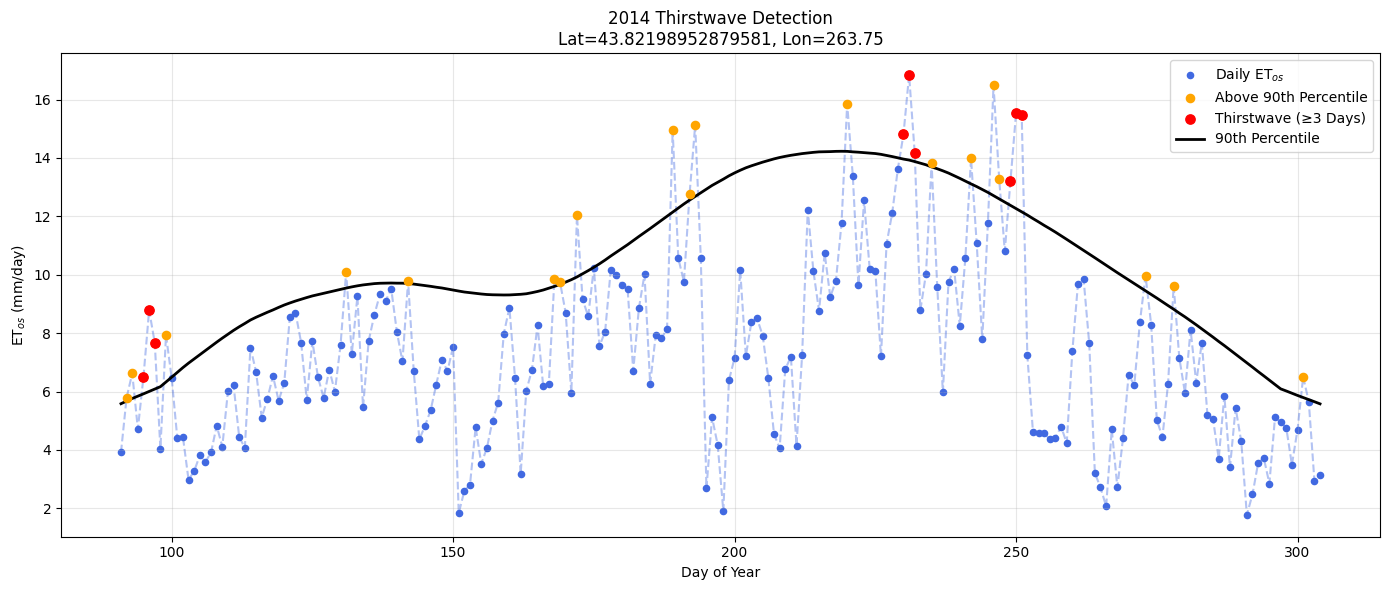

Opening: BSSP370cmip6_LE2-1281.001_ETos_daily.nc
[(92, 97), (120, 123), (127, 134), (136, 139), (173, 176), (211, 214)]

Frequency: 6

Thirstwave characteristics 1
ET_os values: [13.363418 14.98531  16.294981 13.823486 14.187588]
Threshold values: [11.30972984 11.44386705 11.58126142 11.72339887 11.86237213]
Intensity values: [2.05368778 3.54144255 4.71371958 2.10008746 2.32521561]

Thirstwave characteristics 2
ET_os values: [19.066654 15.045428 16.004484]
Threshold values: [14.11828928 14.14782538 14.17017351]
Intensity values: [4.94836492 0.89760289 1.83431067]

Thirstwave characteristics 3
ET_os values: [18.104538 18.838116 16.155643 17.912937 18.683414 19.359138 15.861434]
Threshold values: [14.22459194 14.22729958 14.22433175 14.20768664 14.19596314 14.17921376
 14.16486292]
Intensity values: [3.87994602 4.61081611 1.93131171 3.70525052 4.48745132 5.17992473
 1.69657106]

Thirstwave characteristics 4
ET_os values: [14.964358 21.291555 22.543695]
Threshold values: [14.08479642 14.0

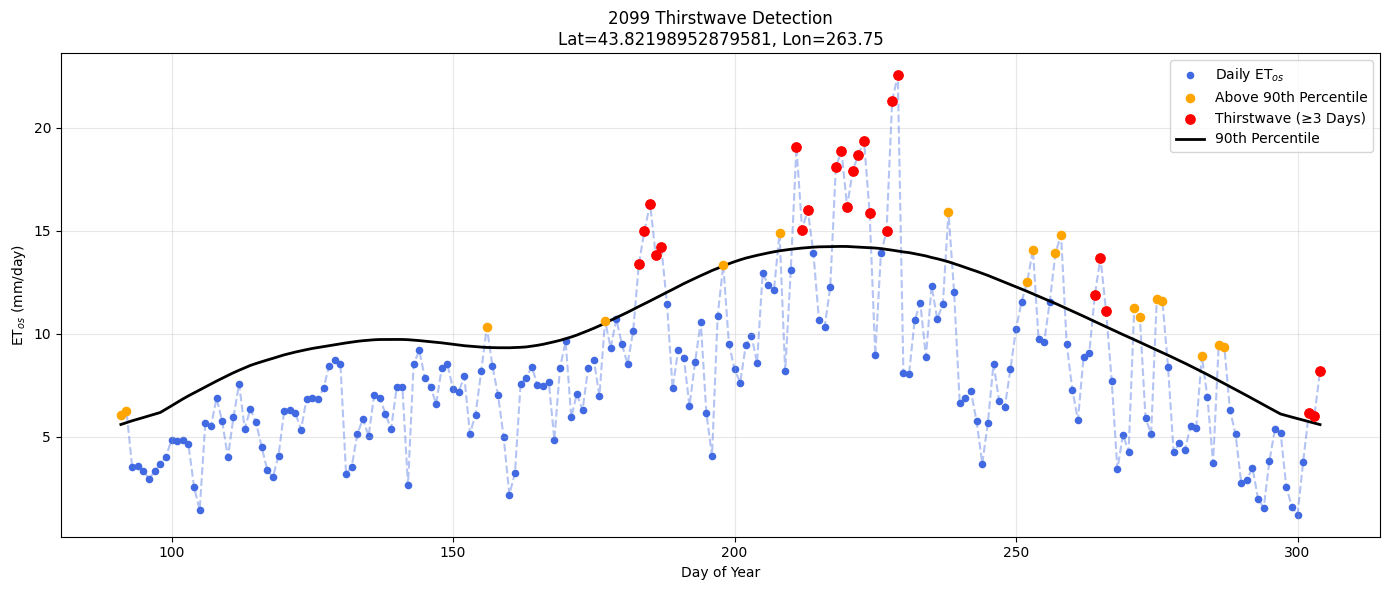

In [14]:
hist_tw_values(AMOC_state=AMOC_state, ensemble_members=ensemble_members, year = 2014)
ftr_tw_values(AMOC_state=AMOC_state, ensemble_members=ensemble_members, year = 2099)

--- Processing All Members for Historical Period ---


/tmp/ipykernel_30744/822152606.py:177: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


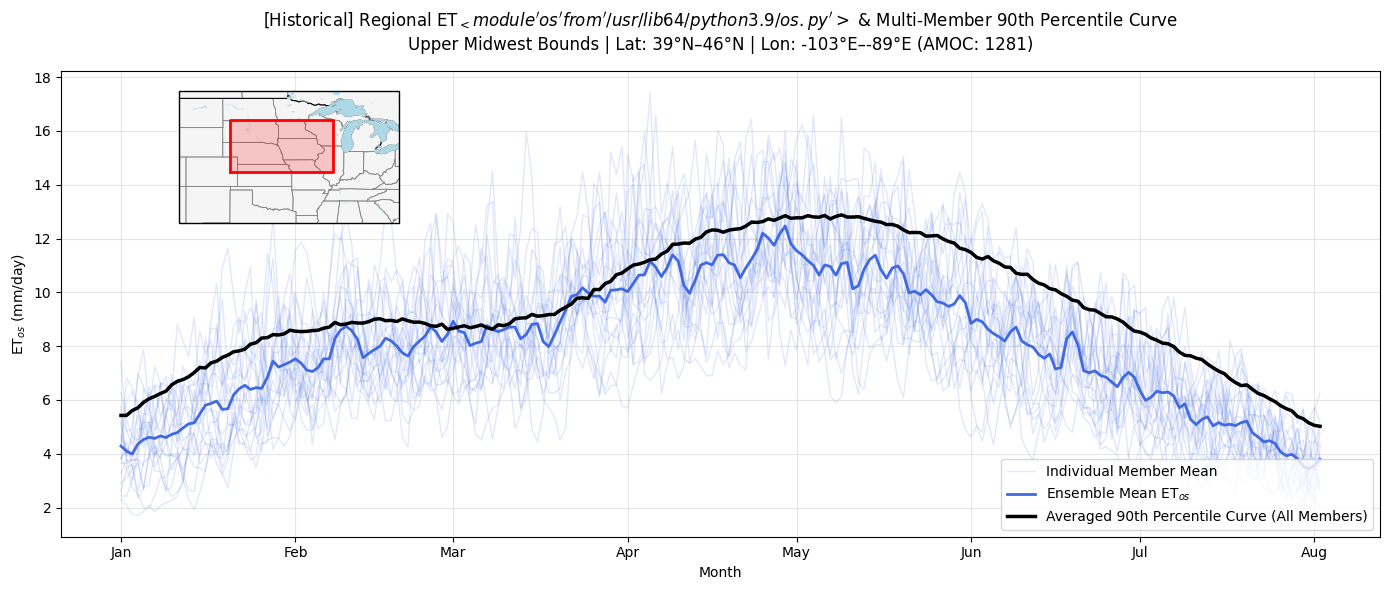

--- Processing All Members for Future Period ---


/tmp/ipykernel_30744/822152606.py:177: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


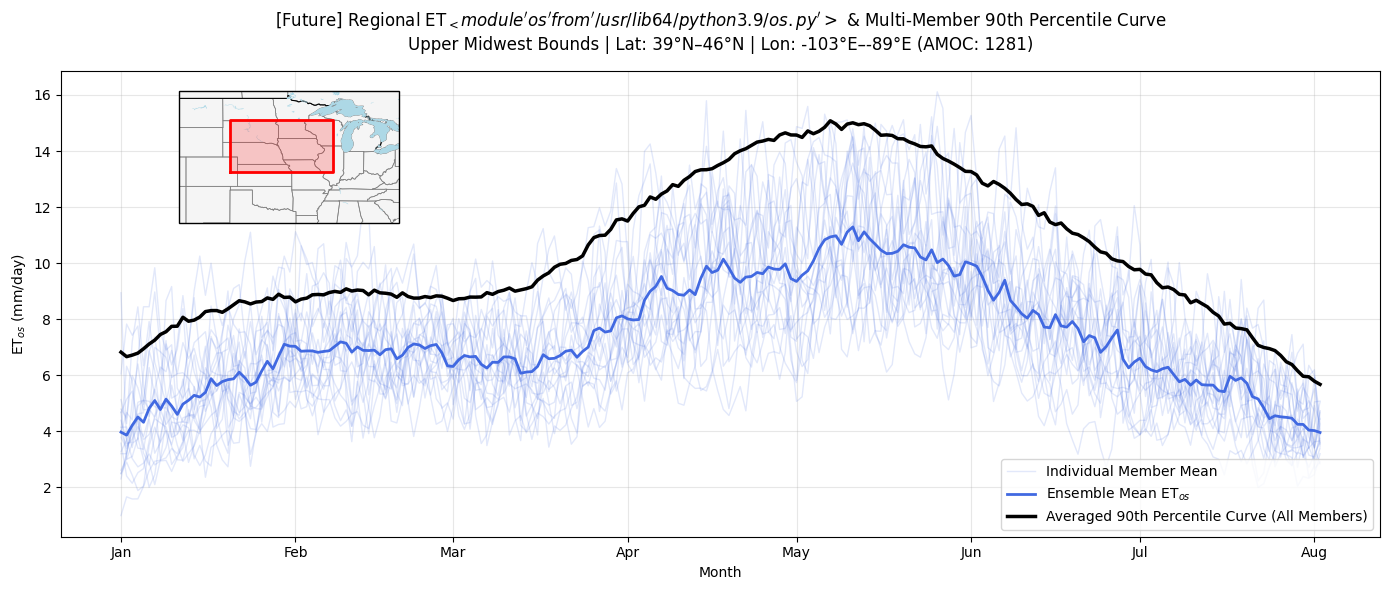

In [5]:
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# ==========================================
# 1. LOAD DATASETS
# ==========================================
baseline = xr.open_zarr("/data1/michsh/90th_zarr/HIST_BASELINE.zarr")
daily_ds_hist = xr.open_zarr(
    "/data1/michsh/combined_thirstwave/HIST_tw_metrics.zarr"
)
daily_ds_ftr = xr.open_zarr(
    "/data1/michsh/combined_thirstwave/FTR_tw_metrics.zarr"
)

# ==========================================
# 2. CONFIGURATION & BOUNDS
# ==========================================
AMOC_state = 1281  # Target AMOC state

# Upper Midwest spatial bounds
w_lon, e_lon, n_lat, s_lat = -103, -89, 46, 39

w_lon_360 = w_lon + 360 if w_lon < 0 else w_lon
e_lon_360 = e_lon + 360 if e_lon < 0 else e_lon

lon_slice = slice(min(w_lon_360, e_lon_360), max(w_lon_360, e_lon_360))
lat_slice = slice(min(s_lat, n_lat), max(s_lat, n_lat))

periods = {"Historical": daily_ds_hist, "Future": daily_ds_ftr}

# ==========================================
# 3. MULTI-MEMBER REGIONAL PROCESSING & PLOTTING
# ==========================================
for period_name, ds in periods.items():
    print(f"--- Processing All Members for {period_name} Period ---")

    # Isolate target AMOC state and slice spatially
    try:
        ds_subset = ds.sel(AMOC=AMOC_state, lat=lat_slice, lon=lon_slice)
    except (ValueError, KeyError):
        ds_subset = ds.sel(AMOC=str(AMOC_state), lat=lat_slice, lon=lon_slice)

    # Calculate cosine latitude weights for grid box size variation
    weights = np.cos(np.deg2rad(ds_subset.lat))
    weights.name = "weights"

    # Compute area-weighted regional mean for ET_os
    weighted_et = ds_subset["ET_os"].weighted(weights)
    member_regional_means = weighted_et.mean(dim=["lat", "lon"])

    # Rechunk the 'member' dimension into a single chunk
    member_regional_means = member_regional_means.chunk({"member": -1})

    # Group by day of year to calculate 90th percentile across time and members
    thirstwave_90th_curve = member_regional_means.groupby(
        "time.dayofyear"
    ).quantile(0.90, dim=["time", "member"])

    # Map the threshold back to a full sample year length
    sample_year = str(member_regional_means.time.dt.year[0].values)
    single_year_data = member_regional_means.sel(time=sample_year)

    # Align 90th percentile curve with sample year timeline
    aligned_threshold = thirstwave_90th_curve.sel(
        dayofyear=single_year_data.time.dt.dayofyear
    )

    # Generate dates for plotting
    fake_dates = pd.date_range(
        start=f"{sample_year}-01-01", periods=len(single_year_data.time), freq="D"
    )

    # ------------------------------------------
    # MAIN FIGURE SETUP
    # ------------------------------------------
    fig, ax = plt.subplots(figsize=(14, 6))

    # Plot individual regional timelines for each ensemble member
    first_member = True
    for m in member_regional_means.member.values:
        member_series = member_regional_means.sel(member=m, time=sample_year)
        ax.plot(
            fake_dates,
            member_series,
            color="royalblue",
            alpha=0.15,
            linewidth=1,
            label="Individual Member Mean" if first_member else "",
        )
        first_member = False

    # Plot ensemble-mean ET_os for sample year
    ensemble_mean_series = single_year_data.mean(dim="member")
    ax.plot(
        fake_dates,
        ensemble_mean_series,
        color="royalblue",
        linewidth=2,
        label="Ensemble Mean ET$_{os}$",
    )

    # Plot calculated 90th percentile curve across members
    ax.plot(
        fake_dates,
        aligned_threshold.values,
        color="black",
        linewidth=2.5,
        linestyle="-",
        label="Averaged 90th Percentile Curve (All Members)",
    )

    # Format Main Axis
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    ax.set_xlabel("Month")
    ax.set_ylabel("ET$_{os}$ (mm/day)")
    ax.set_title(
        f"[{period_name}] Regional ET$_{os}$ & Multi-Member 90th Percentile Curve\n"
        f"Upper Midwest Bounds | Lat: {s_lat}°N–{n_lat}°N | Lon: {w_lon}°E–{e_lon}°E (AMOC: {AMOC_state})",
        pad=15
    )
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right")

    # ------------------------------------------
    # CARTO PY INSET MAP SETUP
    # ------------------------------------------
    # Bounding box in main axes coordinates: [left, bottom, width, height]
    axins = fig.add_axes(
        [0.12, 0.62, 0.18, 0.22], 
        projection=ccrs.PlateCarree()
    )

    # Set map extent to CONUS / Great Lakes region
    axins.set_extent([-110, -80, 32, 50], crs=ccrs.PlateCarree())

    # Add geographical features
    axins.add_feature(cfeature.STATES, edgecolor="gray", linewidth=0.5)
    axins.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.8)
    axins.add_feature(cfeature.LAND, facecolor="#f5f5f5")
    axins.add_feature(cfeature.LAKES, facecolor="lightblue")

    # Draw bounding box on the map corresponding to the spatial slice
    box_lons = [w_lon, e_lon, e_lon, w_lon, w_lon]
    box_lats = [s_lat, s_lat, n_lat, n_lat, s_lat]
    
    axins.plot(
        box_lons,
        box_lats,
        color="red",
        linewidth=2,
        transform=ccrs.PlateCarree(),
        zorder=5
    )
    
    # Optional: Fill region bounded box with transparent red tint
    axins.fill(
        box_lons,
        box_lats,
        color="red",
        alpha=0.2,
        transform=ccrs.PlateCarree(),
        zorder=4
    )

    # Style map spine border
    axins.spines['geo'].set_linewidth(1)
    axins.spines['geo'].set_edgecolor('black')

    plt.tight_layout()
    plt.show()

--- Processing Member 007 (Historical) ---


/tmp/ipykernel_86867/231145501.py:134: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  dates = member_point.indexes["time"].to_datetimeindex()
/tmp/ipykernel_86867/231145501.py:259: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


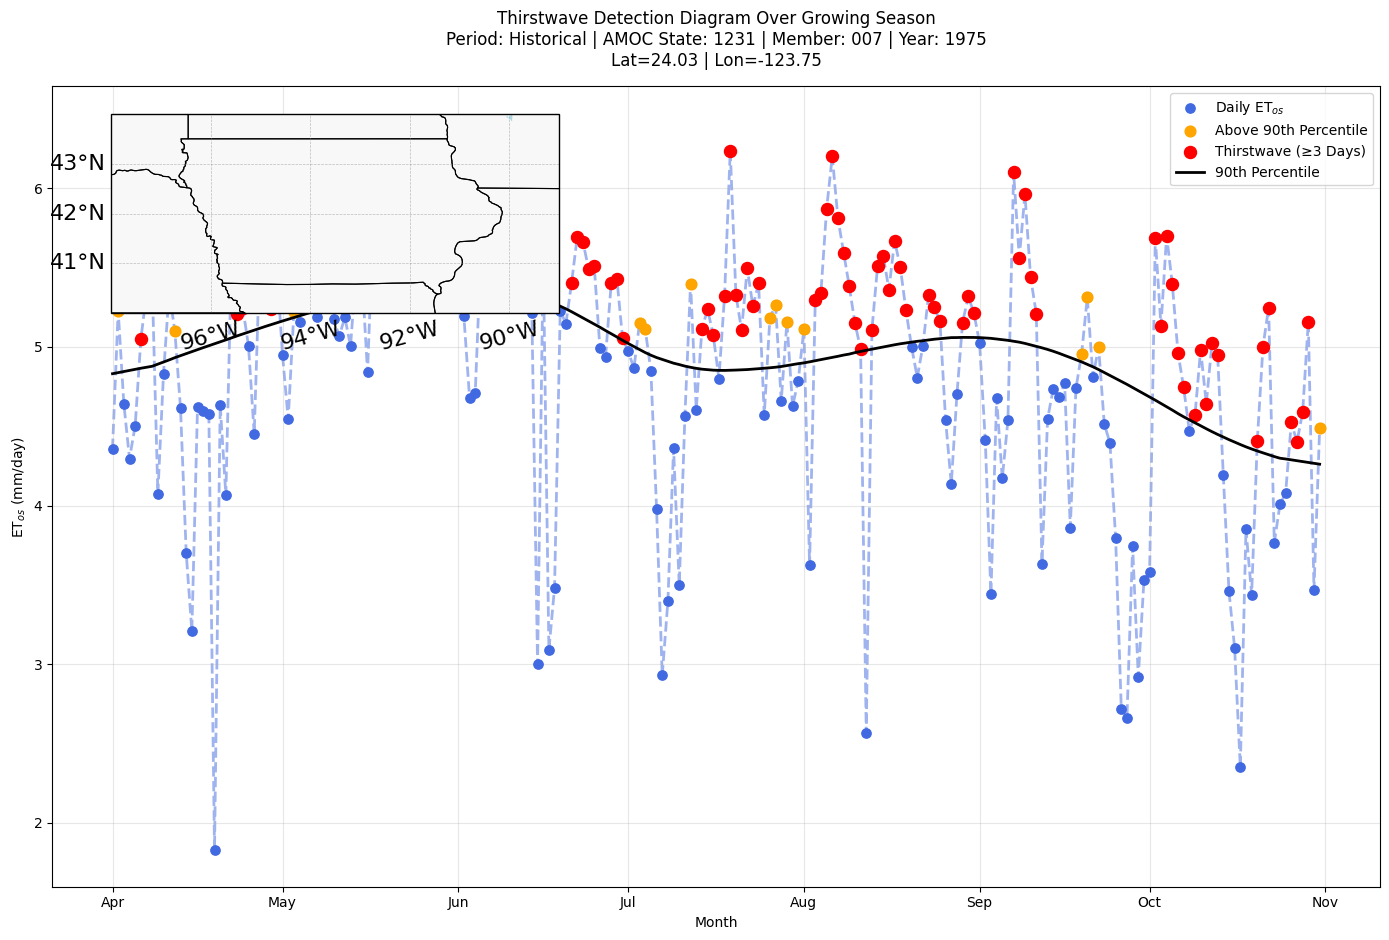

--- Processing Member 007 (Future) ---


/tmp/ipykernel_86867/231145501.py:134: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  dates = member_point.indexes["time"].to_datetimeindex()
/tmp/ipykernel_86867/231145501.py:259: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


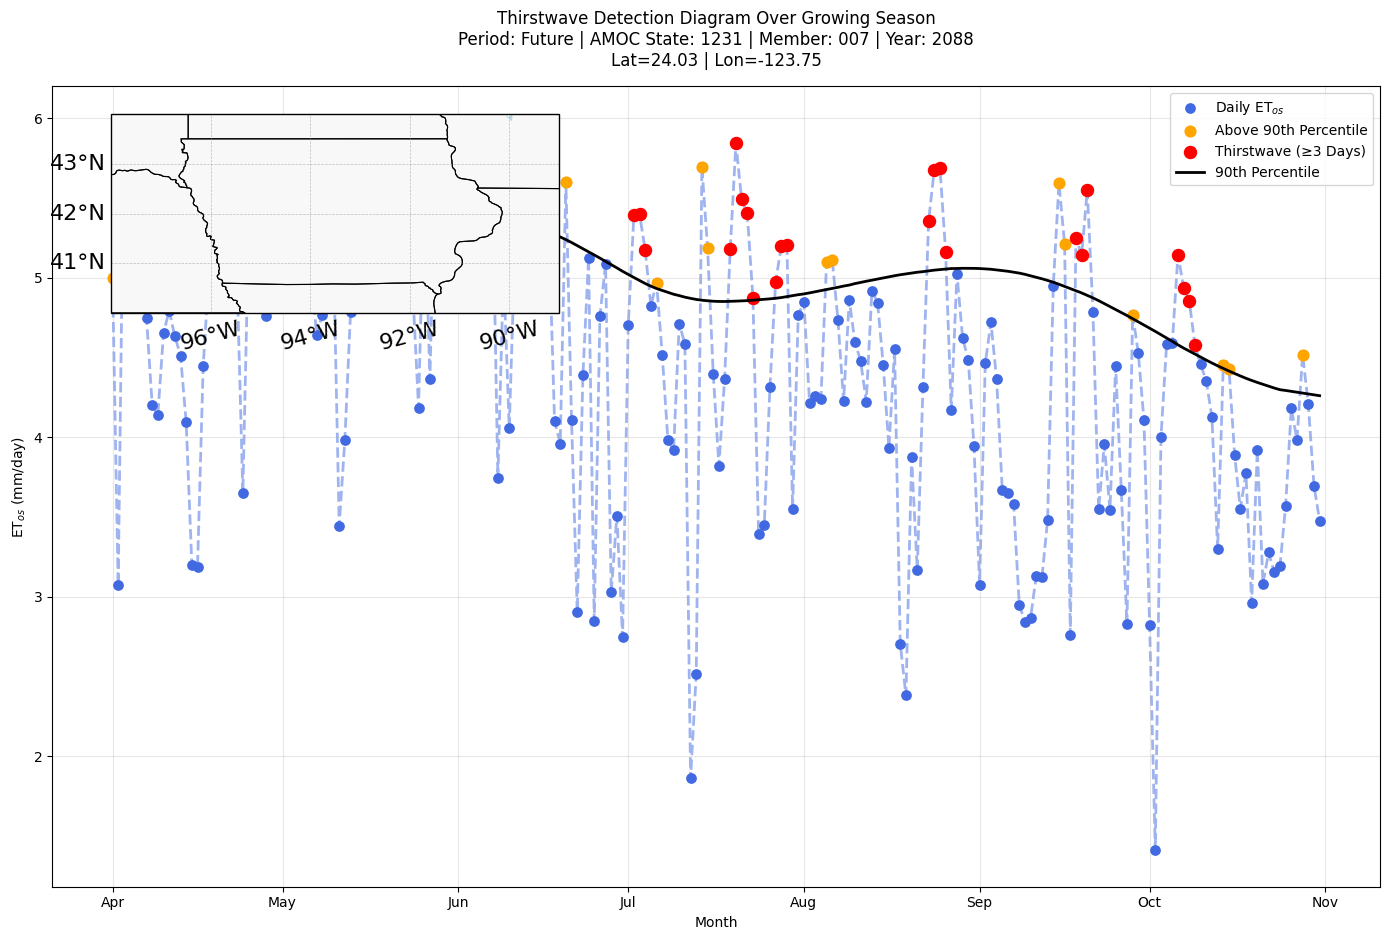

In [133]:
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import xarray as xr

# ==========================================
# 1. LOAD DATASETS
# ==========================================
baseline = xr.open_zarr("/data1/michsh/90th_zarr/HIST_BASELINE.zarr")
daily_ds_hist = xr.open_zarr(
    "/data1/michsh/combined_thirstwave/HIST_tw_metrics.zarr"
)
daily_ds_ftr = xr.open_zarr(
    "/data1/michsh/combined_thirstwave/FTR_tw_metrics.zarr"
)

# ==========================================
# 2. CONFIGURATION & SELECTION
# ==========================================
AMOC_state = 1231  # Target AMOC state
selected_member = "007"  # Target ensemble member

# Iowa Target Location (Center of Iowa / Ames area)
target_lat = 24.031414
target_lon = 236.25 - 360  # Standard degrees West

# Convert longitude to 0-360 range if dataset uses positive lon
target_lon_360 = target_lon + 360 if target_lon < 0 else target_lon

periods = {"Historical": daily_ds_hist, "Future": daily_ds_ftr}

act_lat = baseline["threshold90"].sel(lat=target_lat, method="nearest")
act_lon = baseline["threshold90"].sel(lon=target_lon_360, method="nearest")

actual_lat = float(act_lat.lat.values)
actual_lon = float(act_lon.lon.values)

# Pre-extract baseline 90th percentile threshold for this location
point_threshold = baseline["threshold90"].sel(lat=actual_lat, lon=actual_lon)

# ==========================================
# 3. PROCESSING & PLOTTING
# ==========================================
for period_name, ds in periods.items():
    print(f"--- Processing Member {selected_member} ({period_name}) ---")

    # Select target AMOC state
    try:
        ds_amoc = ds.sel(AMOC=AMOC_state)
    except (ValueError, KeyError):
        ds_amoc = ds.sel(AMOC=str(AMOC_state))

    # Extract single grid point nearest to target coordinates
    point_ds = ds_amoc["ET_os"].sel(
        lat=actual_lat, lon=actual_lon
    )

    plot_lon = actual_lon if actual_lon <= 180 else actual_lon - 360

    # Ensure single chunk for calculation
    point_ds = point_ds.chunk({"member": -1})

    # 1. Explicitly set target year per period
    if period_name == "Historical":
        target_year = 1975
    else:
        target_year = 2088  # Or any valid year in your Future dataset

    # 2. Slice dataset for target year
    try:
        member_point = point_ds.sel(
            member=selected_member,
            time=slice(f"{target_year}-01-01", f"{target_year}-12-31"),
        )
    except (ValueError, KeyError):
        member_point = point_ds.sel(
            member=str(selected_member),
            time=slice(f"{target_year}-01-01", f"{target_year}-12-31"),
        )

    if len(member_point.time) == 0:
        print(
            f"Warning: Year {target_year} returned no data for {period_name}. Skipping..."
        )
        continue

    # 3. Safely calculate dayofyear
    try:
        dayofyear_vals = member_point.time.dt.dayofyear.values
    except AttributeError:
        dayofyear_vals = np.array(
            [t.dayofyear for t in member_point.time.values]
        )

    member_point = member_point.assign_coords(
        dayofyear=("time", dayofyear_vals)
    )
    daily_threshold = point_threshold.sel(dayofyear=member_point.dayofyear)

    # 4. Calculate exceedances
    et_values = member_point.values
    thresh_values = daily_threshold.values
    exceedance_mask = et_values > thresh_values

    # 5. Detect Thirstwave events (consecutive exceedance >= 3 days)
    events = []
    start = None
    for i, above in enumerate(exceedance_mask):
        if above and start is None:
            start = i
        elif not above and start is not None:
            if (i - start) >= 3:
                events.append((start, i))
            start = None

    if start is not None and (len(exceedance_mask) - start) >= 3:
        events.append((start, len(exceedance_mask)))

    # Mark boolean array for thirstwaves
    thirstwave_mask = np.zeros(len(et_values), dtype=bool)
    for s_idx, e_idx in events:
        thirstwave_mask[s_idx:e_idx] = True

    # Isolate non-thirstwave exceedance days (orange points)
    orange_exceedance_mask = exceedance_mask & (~thirstwave_mask)

    # Convert dates for plotting
    try:
        dates = member_point.indexes["time"].to_datetimeindex()
    except AttributeError:
        dates = pd.to_datetime([str(t) for t in member_point.time.values])

    # ------------------------------------------
    # MAIN FIGURE SETUP
    # ------------------------------------------
    fig, ax = plt.subplots(figsize=(14, 9.5))

    # Connecting dashed background line
    ax.plot(
        dates,
        et_values,
        linestyle="--",
        color="royalblue",
        alpha=0.5,
        linewidth=2,
        zorder=1,
    )

    # Standard Daily ET_os Scatter Points
    ax.scatter(
        dates,
        et_values,
        s=45,
        color="royalblue",
        label="Daily ET$_{os}$",
        zorder=2,
    )

    # Exceedance Days (Orange)
    ax.scatter(
        dates[orange_exceedance_mask],
        et_values[orange_exceedance_mask],
        s=60,
        color="orange",
        label="Above 90th Percentile",
        zorder=3,
    )

    # Thirstwave Event Days (Red)
    ax.scatter(
        dates[thirstwave_mask],
        et_values[thirstwave_mask],
        s=75,
        color="red",
        label="Thirstwave (≥3 Days)",
        zorder=4,
    )

    # 90th Percentile Baseline Threshold Line
    ax.plot(
        dates,
        thresh_values,
        color="black",
        linewidth=2,
        label="90th Percentile",
        zorder=5,
    )

    # Format Main Axis with Months
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    ax.set_xlabel("Month")
    ax.set_ylabel("ET$_{os}$ (mm/day)")

    # FIXED TITLE: Uses {target_year} instead of leftover {sample_year}
    ax.set_title(
        f"Thirstwave Detection Diagram Over Growing Season\n"
        f"Period: {period_name} | AMOC State: {AMOC_state} | Member: {selected_member} | Year: {target_year}\n"
        f"Lat={actual_lat:.2f} | Lon={plot_lon:.2f}",
        pad=15,
    )
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="upper right")

    # ------------------------------------------
    # CARTOPY INSET MAP SETUP
    # ------------------------------------------
    axins = fig.add_axes([0.083, 0.61, 0.32, 0.32], projection=ccrs.PlateCarree())

    axins.set_extent([-98, -89, 40, 44], crs=ccrs.PlateCarree())
    axins.add_feature(cfeature.STATES, edgecolor="black", linewidth=0.8)
    axins.add_feature(cfeature.LAND, facecolor="#f8f8f8")
    axins.add_feature(cfeature.LAKES, facecolor="lightblue")

    gl = axins.gridlines(
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    gl.x_inline = False
    gl.y_inline = False
    gl.xpadding = 4
    gl.ypadding = 4

    gl.xlabel_style = {"size": 16, "color": "black", "rotation": 15}
    gl.ylabel_style = {"size": 16, "color": "black"}

    gl.xlocator = mticker.FixedLocator(range(-130, -60, 2))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 1))

    axins.scatter(
        plot_lon,
        actual_lat,
        marker="*",
        color="red",
        s=180,
        edgecolor="black",
        linewidth=0.8,
        zorder=10,
        transform=ccrs.PlateCarree(),
    )

    axins.spines["geo"].set_linewidth(1)
    axins.spines["geo"].set_edgecolor("black")

    plt.tight_layout()
    plt.show()

--- Processing Member 007 (Historical) ---


/tmp/ipykernel_98895/4024707312.py:135: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  dates = member_point.indexes["time"].to_datetimeindex()


-97.5 -90.0 40.137172774869114 43.73717277486911


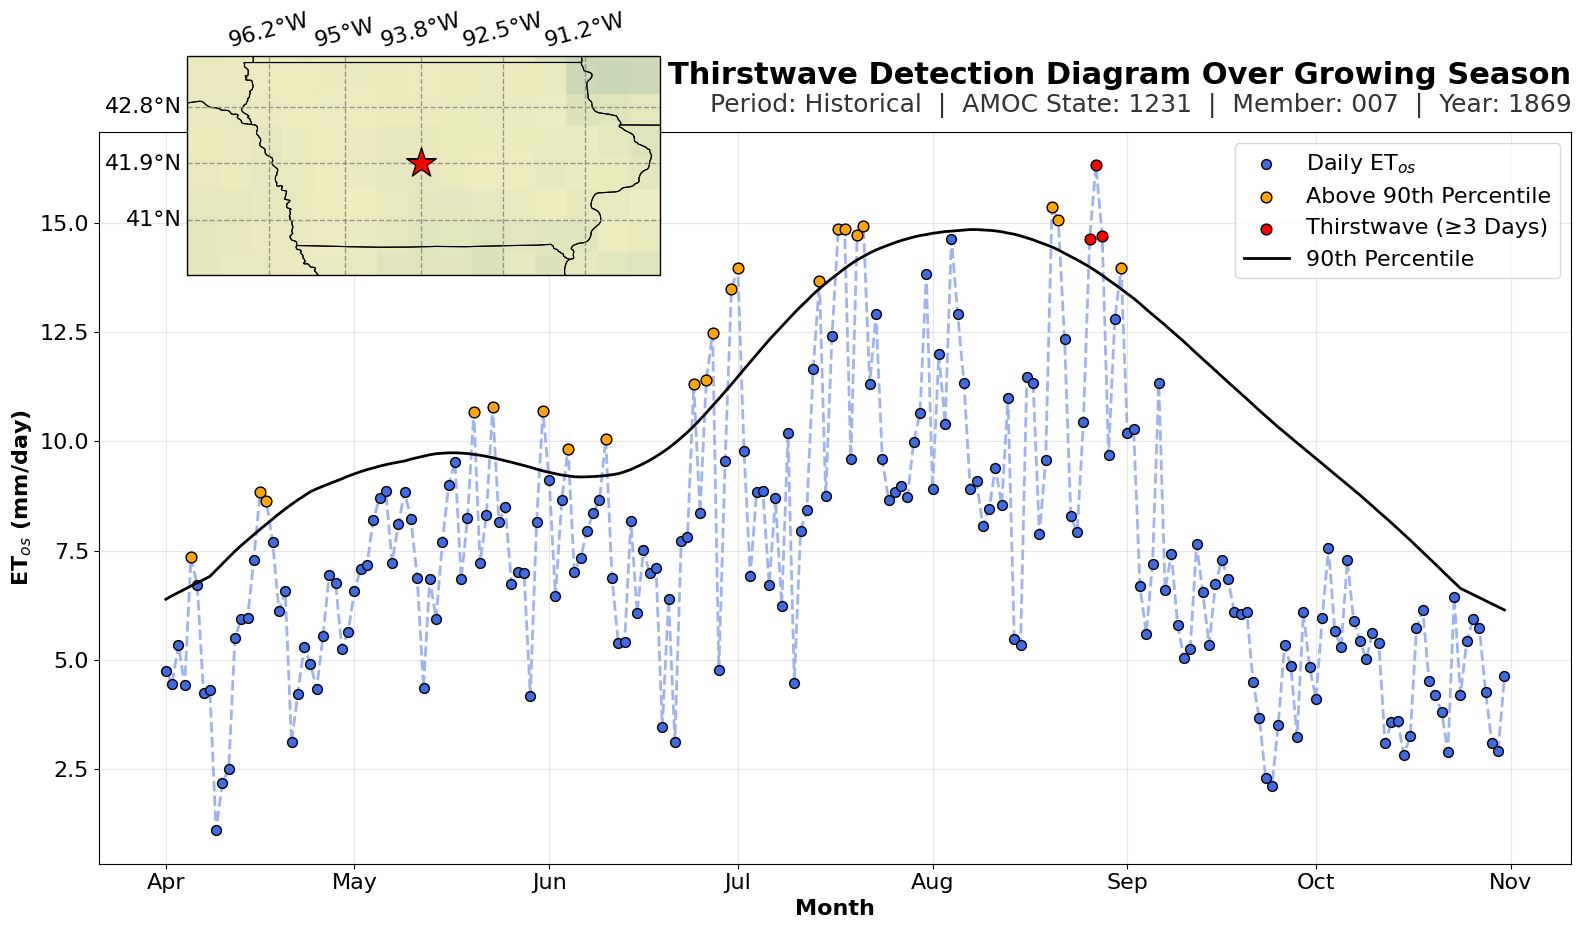

--- Processing Member 007 (Future) ---


/tmp/ipykernel_98895/4024707312.py:135: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  dates = member_point.indexes["time"].to_datetimeindex()


-97.5 -90.0 40.137172774869114 43.73717277486911


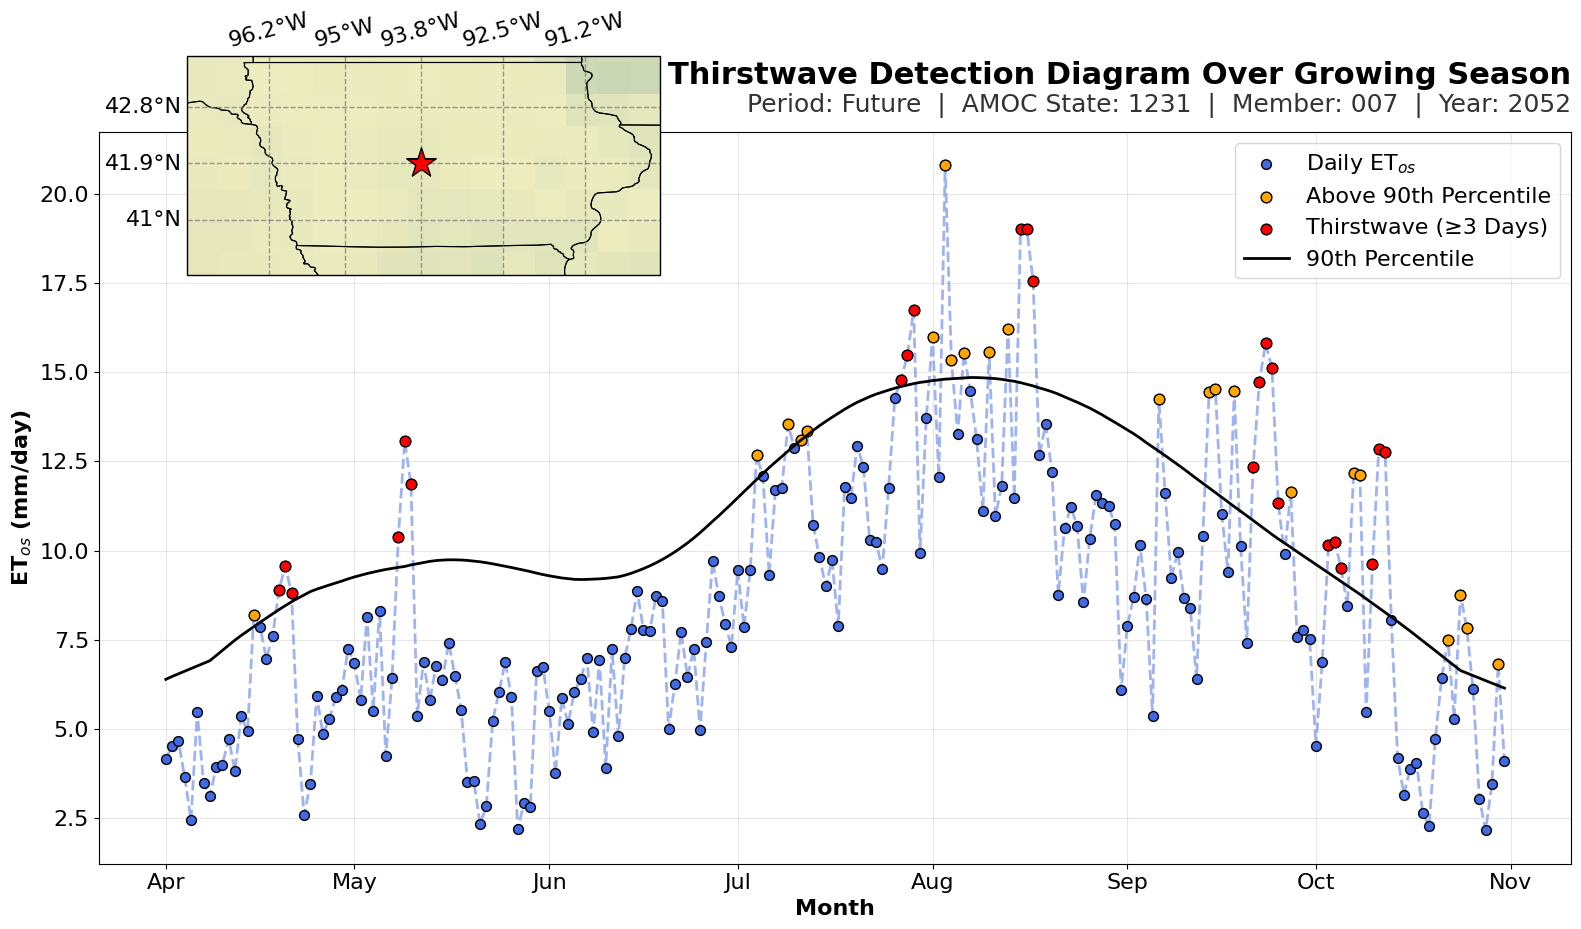

In [4]:
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import xarray as xr

# ==========================================
# 1. LOAD DATASETS
# ==========================================
baseline = xr.open_zarr("/data1/michsh/90th_zarr/HIST_BASELINE.zarr")
daily_ds_hist = xr.open_zarr(
    "/data1/michsh/combined_thirstwave/HIST_tw_metrics.zarr"
)
daily_ds_ftr = xr.open_zarr(
    "/data1/michsh/combined_thirstwave/FTR_tw_metrics.zarr"
)

# ==========================================
# 2. CONFIGURATION & SELECTION
# ==========================================
AMOC_state = 1231  # Target AMOC state
selected_member = "007"  # Target ensemble member # 008 1994

# # Iowa Target Location (Center of Iowa / Ames area)
# target_lat = 42
# target_lon = -94  # Standard degrees West

target_lat = 41.937173
target_lon = 266.25 - 360  # Standard degrees West

# Convert longitude to 0-360 range if dataset uses positive lon
target_lon_360 = target_lon + 360 if target_lon < 0 else target_lon

periods = {"Historical": daily_ds_hist, "Future": daily_ds_ftr}

act_lat = baseline["threshold90"].sel(lat=target_lat, method="nearest")
act_lon = baseline["threshold90"].sel(lon=target_lon_360, method="nearest")

actual_lat = float(act_lat.lat.values)
actual_lon = float(act_lon.lon.values)

# Pre-extract baseline 90th percentile threshold for this location
point_threshold = baseline["threshold90"].sel(lat=actual_lat, lon=actual_lon)

# ==========================================
# 3. PROCESSING & PLOTTING
# ==========================================
for period_name, ds in periods.items():
    print(f"--- Processing Member {selected_member} ({period_name}) ---")

    # Select target AMOC state
    try:
        ds_amoc = ds.sel(AMOC=AMOC_state)
    except (ValueError, KeyError):
        ds_amoc = ds.sel(AMOC=str(AMOC_state))

    # Extract single grid point nearest to target coordinates
    point_ds = ds_amoc["ET_os"].sel(lat=actual_lat, lon=actual_lon)

    plot_lon = actual_lon if actual_lon <= 180 else actual_lon - 360

    # Ensure single chunk for calculation
    point_ds = point_ds.chunk({"member": -1})

    # Explicitly set target year per period
    if period_name == "Historical":
        target_year = 1869
    else:
        target_year = 2052

    # Slice dataset for target year
    try:
        member_point = point_ds.sel(
            member=selected_member,
            time=slice(f"{target_year}-01-01", f"{target_year}-12-31"),
        )
    except (ValueError, KeyError):
        member_point = point_ds.sel(
            member=str(selected_member),
            time=slice(f"{target_year}-01-01", f"{target_year}-12-31"),
        )

    if len(member_point.time) == 0:
        print(
            f"Warning: Year {target_year} returned no data for {period_name}. Skipping..."
        )
        continue

    # Safely calculate dayofyear
    try:
        dayofyear_vals = member_point.time.dt.dayofyear.values
    except AttributeError:
        dayofyear_vals = np.array(
            [t.dayofyear for t in member_point.time.values]
        )

    member_point = member_point.assign_coords(
        dayofyear=("time", dayofyear_vals)
    )
    daily_threshold = point_threshold.sel(dayofyear=member_point.dayofyear)

    # Calculate exceedances
    et_values = member_point.values
    thresh_values = daily_threshold.values
    exceedance_mask = et_values > thresh_values

    # Detect Thirstwave events (consecutive exceedance >= 3 days)
    events = []
    start = None
    for i, above in enumerate(exceedance_mask):
        if above and start is None:
            start = i
        elif not above and start is not None:
            if (i - start) >= 3:
                events.append((start, i))
            start = None

    if start is not None and (len(exceedance_mask) - start) >= 3:
        events.append((start, len(exceedance_mask)))

    # Mark boolean array for thirstwaves
    thirstwave_mask = np.zeros(len(et_values), dtype=bool)
    for s_idx, e_idx in events:
        thirstwave_mask[s_idx:e_idx] = True

    # Isolate non-thirstwave exceedance days
    orange_exceedance_mask = exceedance_mask & (~thirstwave_mask)

    # Convert dates for plotting
    try:
        dates = member_point.indexes["time"].to_datetimeindex()
    except AttributeError:
        dates = pd.to_datetime([str(t) for t in member_point.time.values])

    # ------------------------------------------
    # MAIN FIGURE SETUP
    # ------------------------------------------
    fig, ax = plt.subplots(figsize=(19, 9.5))

    # Connecting dashed background line
    ax.plot(
        dates,
        et_values,
        linestyle="--",
        color="royalblue",
        alpha=0.5,
        linewidth=2,
        zorder=1,
    )

    # Standard Daily ET_os Scatter Points (with black outline)
    ax.scatter(
        dates,
        et_values,
        s=50,
        color="royalblue",
        edgecolor="black",
        linewidth=1,
        label="Daily ET$_{os}$",
        zorder=2,
    )

    # Exceedance Days - Orange (if used)
    ax.scatter(
        dates[orange_exceedance_mask],
        et_values[orange_exceedance_mask],
        s=60,
        color="orange",
        edgecolor="black",
        linewidth=1,
        label="Above 90th Percentile",
        zorder=3,
    )

    # Thirstwave Event Days - Red (with black outline)
    ax.scatter(
        dates[thirstwave_mask],
        et_values[thirstwave_mask],
        s=60,
        color="red",
        edgecolor="black",
        linewidth=1,
        label="Thirstwave (≥3 Days)",
        zorder=4,
    )

    # 90th Percentile Baseline Threshold Line
    ax.plot(
        dates,
        thresh_values,
        color="black",
        linewidth=2,
        label="90th Percentile",
        zorder=5,
    )

    # Format Main Axis Locators and Formatters
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    # Y-AXIS TICKS: Set ticks every 2.5 mm/day
    ax.yaxis.set_major_locator(mticker.MultipleLocator(2.5))

    # Set Font Sizes for Main Plot Labels and Ticks
    ax.set_xlabel("Month", fontsize=16, fontweight="bold")
    ax.set_ylabel("ET$_{os}$ (mm/day)", fontsize=16, fontweight="bold")
    ax.tick_params(axis="both", which="major", labelsize=16)

    # Main Title
    # ------------------------------------------
    # TITLE & SUBTITLE SETUP (Centered Right)
    # ------------------------------------------
    # Main Header (Large & Bold)
    ax.set_title(
        "Thirstwave Detection Diagram Over Growing Season",
        fontsize=22,
        fontweight="bold",
        loc="right",
        pad=35,  # Adds space above the subtitle
    )

    # Sub-metadata (Smaller font, placed right below the main title)
    ax.text(
        1.0, 1.02,  # Coordinates (1.0 = right edge of main plot, 1.02 = slightly above top spine)
        f"Period: {period_name}  |  AMOC State: {AMOC_state}  |  Member: {selected_member}  |  Year: {target_year}",
        transform=ax.transAxes,
        fontsize=18,
        ha="right",      # Align text to the right
        va="bottom",
        color="#333333"   # Slightly muted color for secondary metadata
    )

    ax.grid(True, which="both", alpha=0.3)

    # Legend
    ax.legend(loc="upper right", fontsize=16)

    # ------------------------------------------
    # CARTOPY INSET MAP SETUP
    # ------------------------------------------
    axins = fig.add_axes([0.151, 0.73, 0.29, 0.23], projection=ccrs.PlateCarree())

    axins.set_extent([plot_lon - 1.25 - 1.25 - 1.25, plot_lon + 1.25 + 1.25 + 1.25, actual_lat - 0.9 - 0.9, 43.6], crs=ccrs.PlateCarree())
    axins.add_feature(cfeature.STATES, edgecolor="black", linewidth=0.8)
    axins.add_feature(cfeature.LAND, facecolor="#f8f8f8")
    axins.stock_img()

    gl = axins.gridlines(
        draw_labels=True,
        linewidth=1,
        color="grey",
        alpha=0.8,
        linestyle="--",
        zorder=4,
    )

    gl.top_labels = True
    gl.right_labels = False
    gl.bottom_labels = False
    gl.left_labels = True
    gl.x_inline = False
    gl.y_inline = False
    gl.xpadding = 4
    gl.ypadding = 4

    # Map Coordinates Font Size set to 16
    gl.xlabel_style = {"size": 16, "color": "black", "rotation": 15}
    gl.ylabel_style = {"size": 16, "color": "black"}

    # Gridlines centered on target lon/lat with requested offsets (1.3° lon, 0.9° lat)
    gl.xlocator = mticker.FixedLocator(
        np.round([plot_lon - 1.25 - 1.25 - 1.25, plot_lon - 1.25 - 1.25, plot_lon - 1.25, plot_lon, plot_lon + 1.25, plot_lon + 1.25 + 1.25, plot_lon + 1.25 + 1.25 + 1.25], 1)
    )
    gl.ylocator = mticker.FixedLocator(
        np.round([actual_lat - 0.9 - 0.9, actual_lat - 0.9, actual_lat, actual_lat + 0.9, actual_lat + 0.9 + 0.9], 1)
    )

    print(plot_lon - 1.25 - 1.25 - 1.25, plot_lon + 1.25 + 1.25 + 1.25, actual_lat - 0.9 - 0.9, actual_lat + 0.9 + 0.9)

    # Plot Star at Target Point
    axins.scatter(
        np.round(plot_lon, 1),
        np.round(actual_lat, 1),
        marker="*",
        color="red",
        s=500,
        edgecolor="black",
        linewidth=1,
        zorder=10,
        transform=ccrs.PlateCarree(),
    )

    axins.spines["geo"].set_linewidth(1)
    axins.spines["geo"].set_edgecolor("black")

    plt.show()

# Open the new files and plot them

In [2]:
daily_ds_hist = xr.open_zarr(
    "/data1/michsh/combined_thirstwave/HIST_tw_metrics.zarr"
)

daily_ds_ftr = xr.open_zarr(
    "/data1/michsh/combined_thirstwave/FTR_tw_metrics.zarr"
)

daily_ds_ftr

<xarray.Dataset> Size: 33GB
Dimensions:               (AMOC: 4, member: 20, time: 18404, lat: 30, lon: 47,
                           year: 86)
Coordinates:
  * AMOC                  (AMOC) object 32B '1231' '1251' '1281' '1301'
    dayofyear             (time) float64 147kB dask.array<chunksize=(18404,), meta=np.ndarray>
  * lat                   (lat) float64 240B 24.03 24.97 25.92 ... 50.42 51.36
  * lon                   (lon) float64 376B 235.0 236.2 237.5 ... 291.2 292.5
  * member                (member) object 160B '001' '002' '003' ... '019' '020'
  * time                  (time) object 147kB 2015-04-01 00:00:00 ... 2100-10...
  * year                  (year) int64 688B 2015 2016 2017 ... 2098 2099 2100
Data variables:
    ET_os                 (AMOC, member, time, lat, lon) float32 8GB dask.array<chunksize=(1, 1, 18404, 25, 25), meta=np.ndarray>
    actual_tw_ET_os       (AMOC, member, time, lat, lon) float32 8GB dask.array<chunksize=(1, 1, 18404, 25, 25), meta=np.ndarray>
    event_id              (AMOC, member, lat, lon, time) int32 8GB dask.array<chunksize=(1, 1, 25, 25, 18404), meta=np.ndarray>
    thirstwave_frequency  (year, AMOC, member, lat, lon) int32 39MB dask.array<chunksize=(1, 1, 1, 25, 25), meta=np.ndarray>
    tw_intensity          (AMOC, member, time, lat, lon) float32 8GB dask.array<chunksize=(1, 1, 18404, 25, 25), meta=np.ndarray>

In [9]:
import numpy as np

# 1. Take the mean over time, then stack the AMOC and member dimensions to get 80 members
intensity_hist = daily_ds_hist['tw_intensity'].mean(dim=['time'])
stacked_hist = intensity_hist.stack(ensemble_80=('AMOC', 'member'))

# 2. Extract the 80 values for your specific grid point
# Using .values converts the Xarray data into a clean, easy-to-use NumPy array
hist_member_point_avg = stacked_hist.sel(lat=39, lon=276, method='nearest').values

# 3. Calculate the Mean across all 80 members
point_mean = np.mean(hist_member_point_avg)

# 4. Calculate Sigma (Standard Deviation)
# We use ddof=1 for "sample standard deviation" which is standard in climate statistics
point_sigma = np.std(hist_member_point_avg, ddof=1)

# --- Print the Results ---
print("--- Results for Grid Point (Lat: 38, Lon: 278) ---")
print(f"Number of members analyzed (n): {len(hist_member_point_avg)}")
print("\nIndividual Member Means:")
# Rounding the list for clean printing
print(np.round(hist_member_point_avg, 3)) 

print("\n" + "="*40)
print(f"Historical Mean Value:  {point_mean:.4f}")
print(f"Historical Sigma (std): {point_sigma:.4f}")
print("="*40)

# =================================================================================================

# 1. Take the mean over time and stack the future dataset
intensity_ftr = daily_ds_ftr['tw_intensity'].mean(dim=['time'])
stacked_ftr = intensity_ftr.stack(ensemble_80=('AMOC', 'member'))

# 2. Extract the 80 future values for the same grid point
ftr_member_point_avg = stacked_ftr.sel(lat=38, lon=278, method='nearest').values

# 3. Calculate the Future Mean and Sigma
ftr_point_mean = np.mean(ftr_member_point_avg)
ftr_point_sigma = np.std(ftr_member_point_avg, ddof=1)

print("--- Results for Grid Point (Lat: 38, Lon: 278) ---")
print(f"Number of members analyzed (n): {len(ftr_member_point_avg)}")
print("\nIndividual Member Means:")
# Rounding the list for clean printing
print(np.round(ftr_member_point_avg, 3)) 

print("\n" + "="*40)
print(f"Historical Mean Value:  {ftr_point_mean:.4f}")
print(f"Historical Sigma (std): {ftr_point_sigma:.4f}")
print("="*40)

--- Results for Grid Point (Lat: 38, Lon: 278) ---
Number of members analyzed (n): 80

Individual Member Means:
[1.358 1.269 1.366 1.373 1.303 1.364 1.358 1.384 1.369 1.379 1.42  1.365
 1.4   1.38  1.388 1.411 1.374 1.433 1.32  1.376 1.365 1.316 1.331 1.367
 1.408 1.368 1.41  1.356 1.293 1.372 1.341 1.366 1.238 1.406 1.331 1.396
 1.265 1.249 1.359 1.439 1.365 1.304 1.273 1.238 1.259 1.307 1.364 1.37
 1.432 1.336 1.38  1.362 1.356 1.311 1.291 1.326 1.308 1.389 1.383 1.221
 1.332 1.371 1.318 1.352 1.376 1.382 1.427 1.333 1.424 1.291 1.391 1.23
 1.317 1.346 1.433 1.443 1.349 1.374 1.324 1.451]

Historical Mean Value:  1.3526
Historical Sigma (std): 0.0529
--- Results for Grid Point (Lat: 38, Lon: 278) ---
Number of members analyzed (n): 80

Individual Member Means:
[1.176 1.16  1.167 1.118 1.138 1.143 1.142 1.134 1.166 1.116 1.134 1.158
 1.16  1.144 1.136 1.205 1.237 1.214 1.168 1.22  1.119 1.135 1.172 1.205
 1.157 1.2   1.193 1.192 1.16  1.072 1.164 1.192 1.171 1.152 1.114 1.171
 1.192 1

In [4]:
from scipy import stats

# This runs the pooled t-test on your two 80-member arrays
t_stat, p_val = stats.ttest_ind(ftr_member_point_avg, hist_member_point_avg, equal_var=True)

print("--- Single Point T-Test Results ---")
print(f"Difference in Means: {ftr_point_mean - 1.2199:.4f}")
print(f"T-statistic:         {t_stat:.4f}")
print(f"P-value:             {p_val:.4e}")

if p_val < 0.05:
    print("Conclusion: Significant change! This point gets stippled.")
else:
    print("Conclusion: Not statistically significant.")

--- Single Point T-Test Results ---
Difference in Means: -0.0559
T-statistic:         18.0963
P-value:             2.3595e-40
Conclusion: Significant change! This point gets stippled.


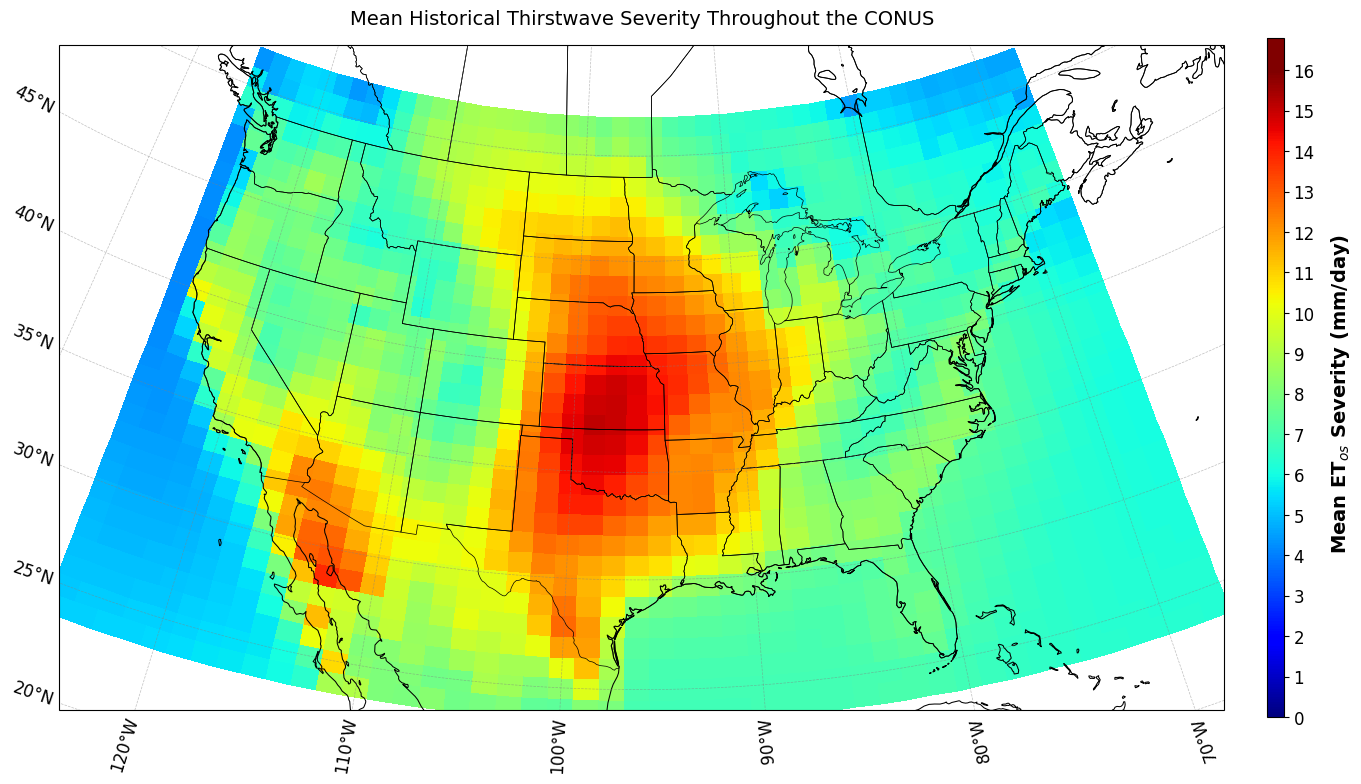

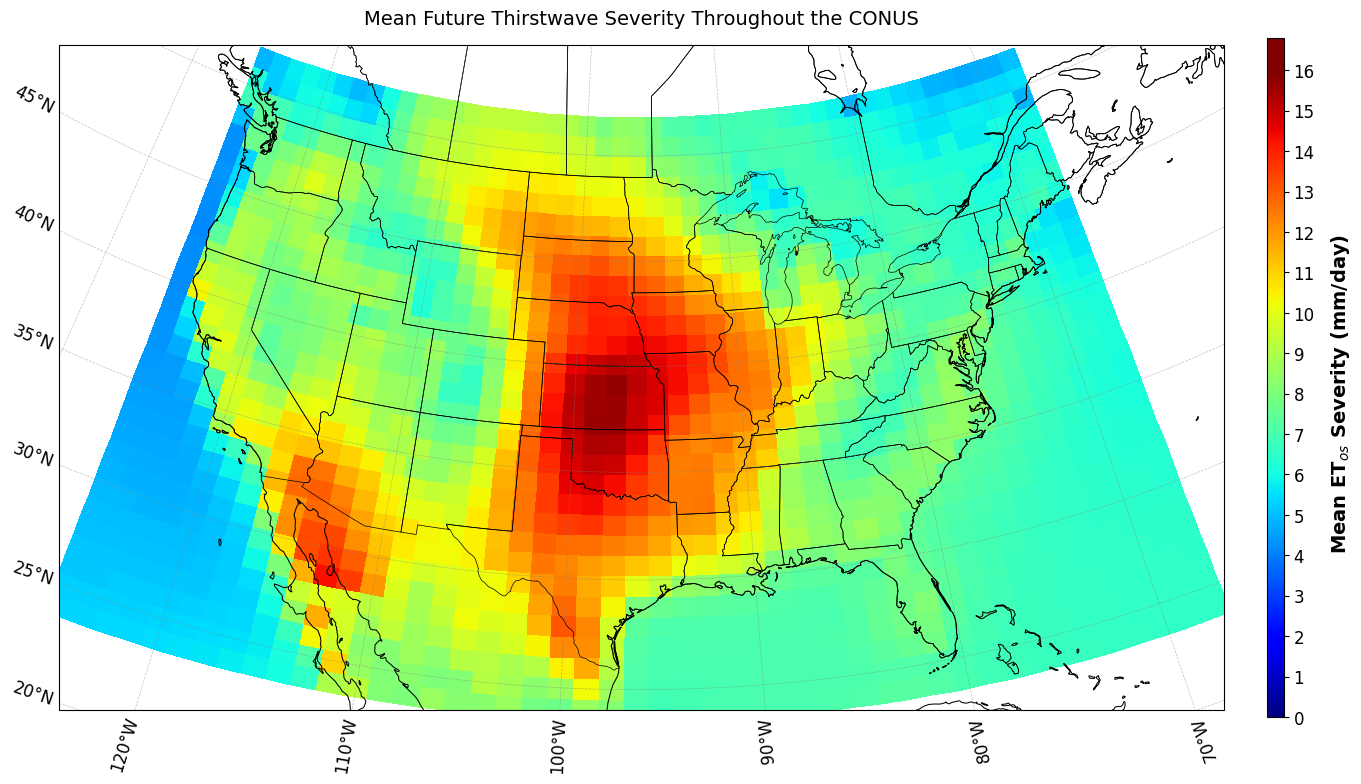

In [ ]:
mean_severity_hist = daily_ds_hist['actual_tw_ET_os'].mean(dim=['AMOC', 'member', 'time'])
mean_severity_ftr = daily_ds_ftr['actual_tw_ET_os'].mean(dim=['AMOC', 'member', 'time'])

# Pair each DataArray with its specific title to avoid the array-comparison bug
plots_and_titles = [
    (mean_severity_hist, 'Mean Historical Thirstwave Severity Throughout the CONUS'),
    (mean_severity_ftr, 'Mean Future Thirstwave Severity Throughout the CONUS')
]

for plot, title in plots_and_titles:
    # Define the plot bounds 
    s_lat, n_lat = 24, 52
    w_lon, e_lon = -125, -67

    # Bounding box matching the Lambert Conformal format
    crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

    # Create the plot
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=crs)

    # Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    # Map features
    ax.coastlines('50m', linewidth=0.75)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.5)

    # Calculate ticks dynamically based on the max value
    data_max = float(plot.max())
    max_even = int(np.ceil(data_max / 2) * 2)
    
    # Safeguard step size so you don't end up with hundreds of ticks if max_even is large
    tick_step = max(1, max_even // 10) 
    custom_ticks = list(range(0, max_even + 1, tick_step))

    # Render the background color fill
    im = plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='jet', 
                   add_colorbar=False, vmin=0.0, vmax=max_even, robust=True)

    # Drawing gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                      color='gray', alpha=0.5, linestyle='--')

    # Restrict labels to ONLY the bottom and left
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # Style the labels
    gl.xlabel_style = {'size': 12, 'color': 'black'}
    gl.ylabel_style = {'size': 12, 'color': 'black'}

    # Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

    # Vertical colorbar configuration (Now unified for both plots)
    cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                      aspect=40, extend='max', extendrect=True, ticks=custom_ticks) 

    # Colorbar label settings with nice subscripts
    cb.set_label('Mean ET$_{os}$ Severity (mm/day)', size=14, weight='bold', labelpad=10)
    cb.ax.tick_params(labelsize=12)

    # Dynamic Title
    plt.title(title, fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

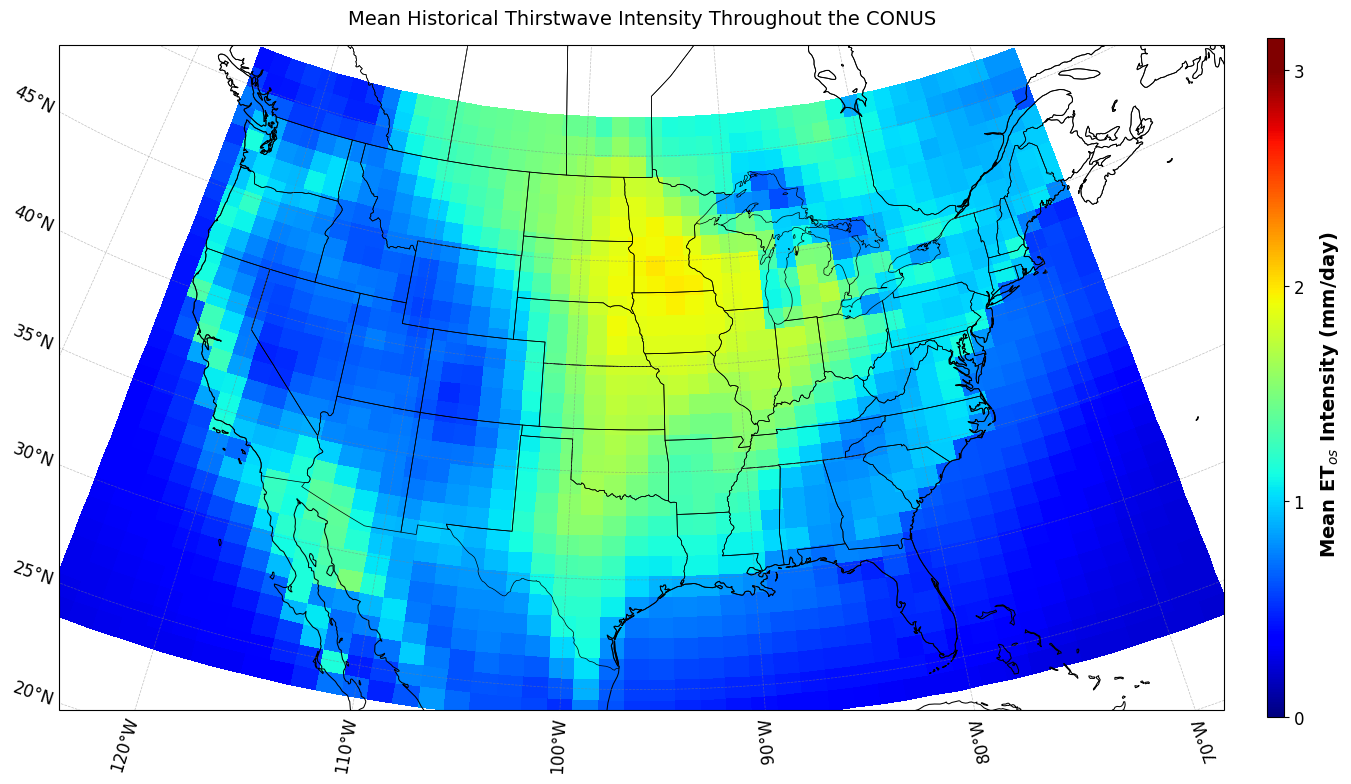

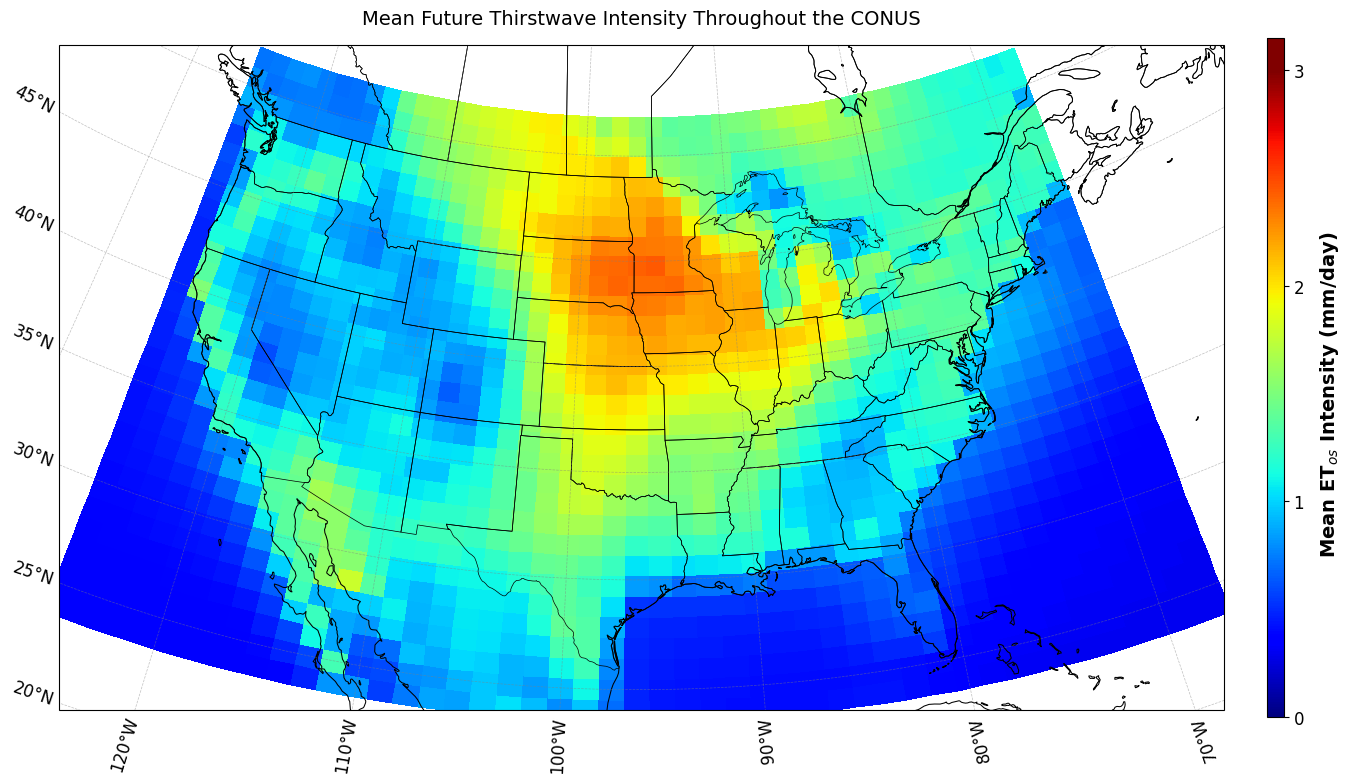

In [ ]:
intensity_hist = daily_ds_hist['tw_intensity'].mean(dim=['AMOC', 'member', 'time'])
intensity_ftr = daily_ds_ftr['tw_intensity'].mean(dim=['AMOC', 'member', 'time'])

# Pair each intensity array with its respective correct title
plots_and_titles = [
    (intensity_hist, 'Mean Historical Thirstwave Intensity Throughout the CONUS'),
    (intensity_ftr, 'Mean Future Thirstwave Intensity Throughout the CONUS')
]

for plot, title in plots_and_titles:
    # Define the plot bounds 
    s_lat, n_lat = 24, 52
    w_lon, e_lon = -125, -67

    # Bounding box matching the Lambert Conformal format
    crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

    # Create the plot
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=crs)

    # Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    # Map features
    ax.coastlines('50m', linewidth=0.75)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.5)

    # Calculate ticks dynamically based on the newly calculated data
    
    # Dynamic tick step to prevent overcrowding if the intensity scale is large
    tick_step = max(1, max_even // 10)
    custom_ticks = list(range(0, max_even + 1, tick_step))

    # Render the background color fill using intensity data
    im = plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='jet', 
                   add_colorbar=False, vmin=0.0, vmax=3, robust=True)

    # Drawing gridlines using PlateCarree ensures latitude lines are straight and parallel
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                      color='gray', alpha=0.5, linestyle='--')

    # Restrict labels to ONLY the bottom (for longitude) and left (for latitude)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # Style the labels
    gl.xlabel_style = {'size': 12, 'color': 'black'}
    gl.ylabel_style = {'size': 12, 'color': 'black'}

    # Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

    # Unified Vertical colorbar configuration
    cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                      aspect=40, extend='max', extendrect=True, ticks=custom_ticks) 

    # Colorbar label settings with nice subscripts
    cb.set_label('Mean ET$_{os}$ Intensity (mm/day)', size=14, weight='bold', labelpad=10)
    cb.ax.tick_params(labelsize=12)

    # Title
    plt.title(title, fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

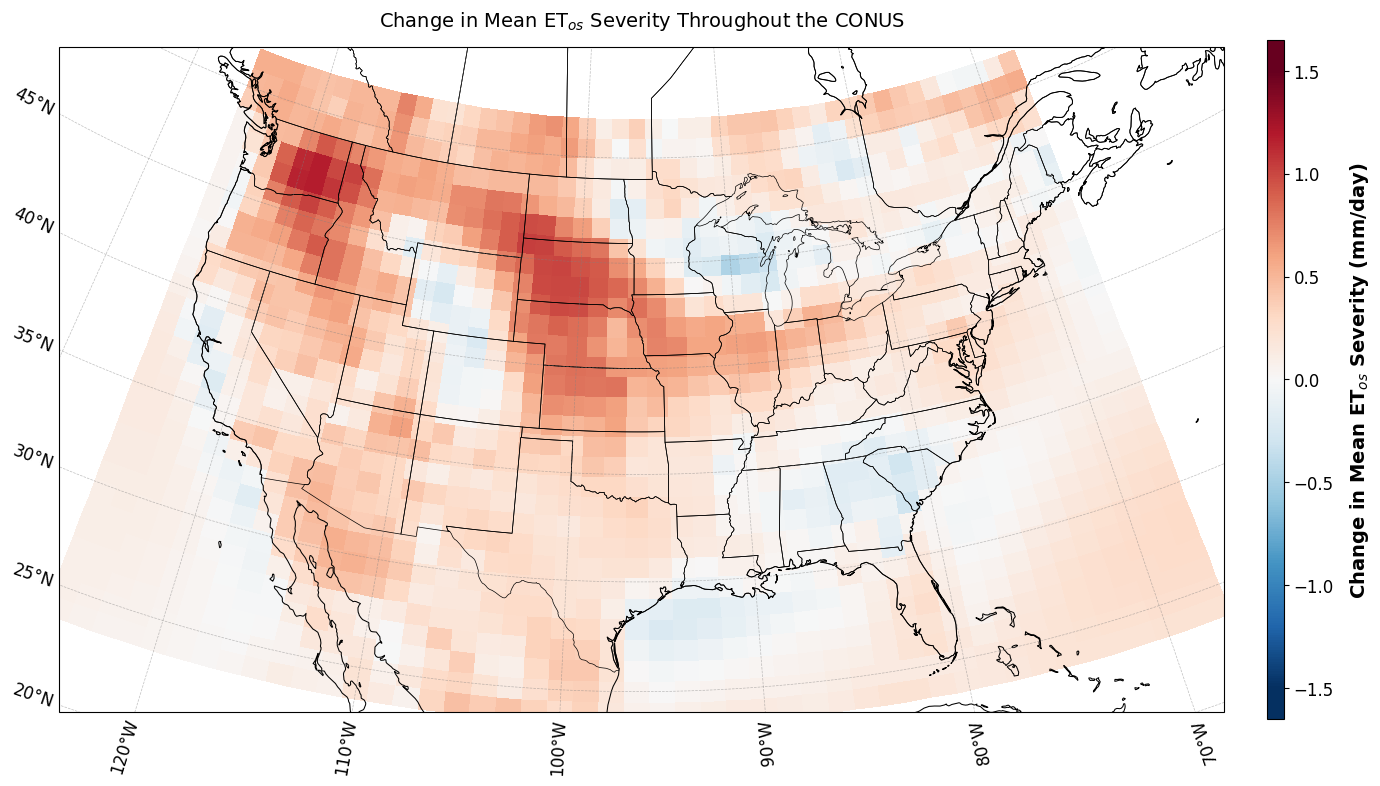

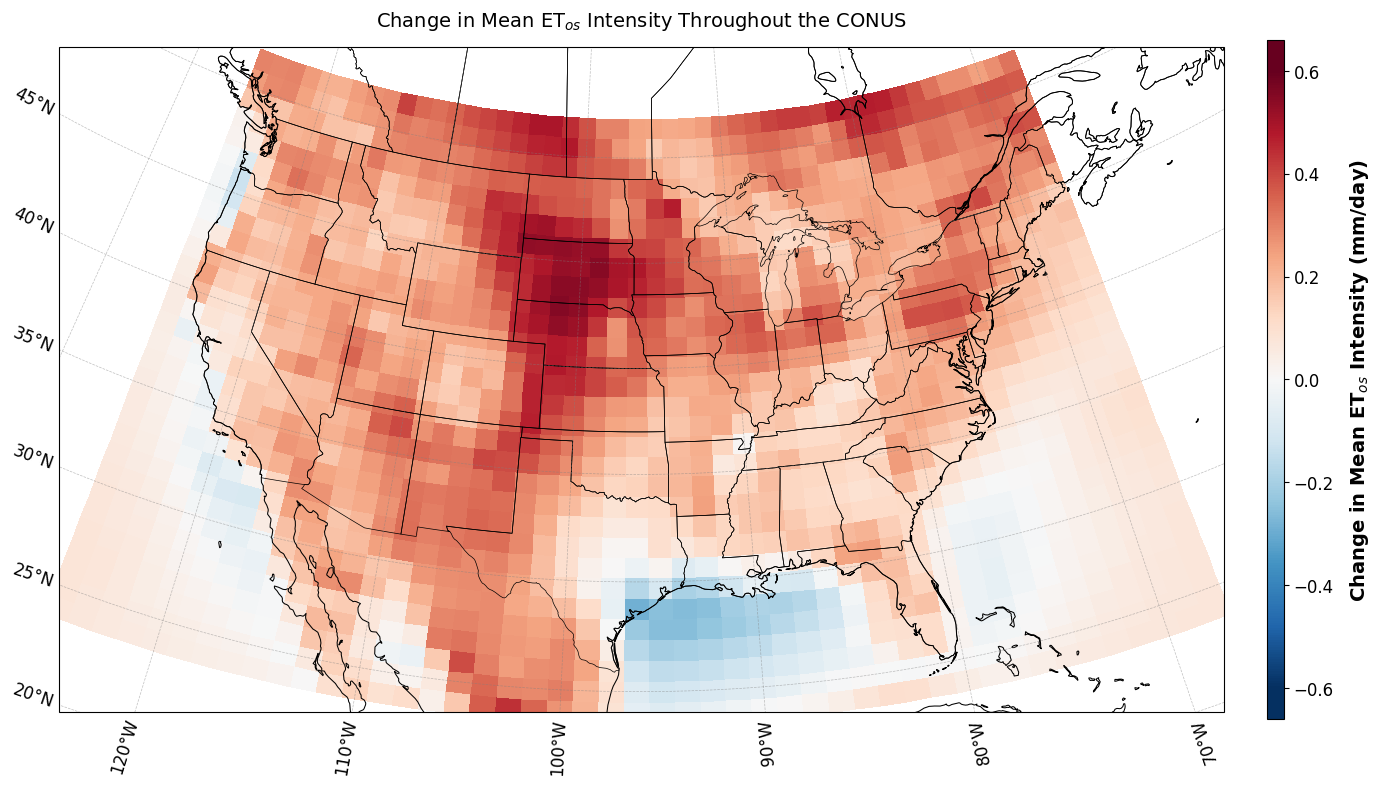

In [ ]:
mean_delta_hist = mean_severity_ftr - mean_severity_hist
delta_intensity = intensity_ftr - intensity_hist  

# Pair each delta array with its unique colorbar label and plot title
plots_and_metadata = [
    (mean_delta_hist, 'Change in Mean ET$_{os}$ Severity (mm/day)', 'Change in Mean ET$_{os}$ Severity Throughout the CONUS'),
    (delta_intensity, 'Change in Mean ET$_{os}$ Intensity (mm/day)', 'Change in Mean ET$_{os}$ Intensity Throughout the CONUS'),
]

for plot, cb_label, title in plots_and_metadata:
    # Define the plot bounds 
    s_lat, n_lat = 24, 52
    w_lon, e_lon = -125, -67

    # Bounding box matching the Lambert Conformal format
    crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

    # Create the plot
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=crs)

    # Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    # Map features
    ax.coastlines('50m', linewidth=0.75)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.5)

    # --- DYNAMIC SYMMETRIC RANGE SELECTION ---
    abs_max = max(abs(float(plot.min())), abs(float(plot.max())))

    if abs_max <= 1.0:
        vmax = np.ceil(abs_max * 5) / 5  # Rounds up to nearest 0.2
        tick_step = 0.2
    elif abs_max <= 2.5:
        vmax = np.ceil(abs_max * 2) / 2  # Rounds up to nearest 0.5
        tick_step = 0.5
    else:
        vmax = float(np.ceil(abs_max))   # Rounds up to nearest integer
        tick_step = 1.0

    vmin = -vmax

    # --- CREATE SYMMETRIC TICKS ---
    custom_ticks = np.arange(vmin, vmax + (tick_step * 0.5), tick_step)

    # --- RENDER WITH BALANCED LIMITS ---
    im = plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', 
                   add_colorbar=False, vmin=vmin, vmax=vmax, robust=True)

    # Drawing gridlines using PlateCarree ensures latitude lines are straight and parallel
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                      color='gray', alpha=0.5, linestyle='--')

    # Restrict labels to ONLY the bottom (for longitude) and left (for latitude)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # Style the labels
    gl.xlabel_style = {'size': 12, 'color': 'black'}
    gl.ylabel_style = {'size': 12, 'color': 'black'}

    # Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

    # Unified Vertical colorbar configuration 
    cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                      aspect=40, extend='both', extendrect=True, ticks=custom_ticks) 

    # Dynamic colorbar label settings with nice subscripts
    cb.set_label(cb_label, size=14, weight='bold', labelpad=10)
    cb.ax.tick_params(labelsize=12)

    # Dynamic Title 
    plt.title(title, fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

In [25]:


# --- INPUT YOUR TARGET MONTH HERE ---
# 1 = January, 2 = February, ..., 12 = December
target_month = 4  # Example: July

# Pair each delta array with its unique colorbar label and plot title
plots_and_metadata = [
    (mean_delta_hist, 'Change in Mean ET$_{os}$ Severity (mm/day)', 'Change in Mean ET$_{os}$ Severity Throughout the CONUS'),
    (delta_intencity, 'Change in Mean ET$_{os}$ Intensity (mm/day)', 'Change in Mean ET$_{os}$ Intensity Throughout the CONUS')
]

month_bounds = {
    1: (1, 31),     2: (32, 59),    3: (60, 90),
    4: (91, 120),   5: (121, 151),  6: (152, 181),
    7: (182, 212),  8: (213, 243),  9: (244, 273),
    10: (274, 304), 11: (305, 334), 12: (335, 365)
}
month_names = {
    1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June",
    7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"
}

start_day, end_day = month_bounds[target_month]
month_name = month_names[target_month]

for plot_data, cb_label, title in plots_and_metadata:
    
    # Slice along the 'dayofyear' dimension and take the mean
    plot = plot_data.sel(dayofyear=slice(start_day, end_day)).mean(dim='dayofyear')
    
    dynamic_title = f"{title} ({month_name})"

    # Define the plot bounds 
    s_lat, n_lat = 24, 52
    w_lon, e_lon = -125, -67

    # Bounding box matching the Lambert Conformal format
    crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

    # Create the plot
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=crs)

    # Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    # Map features
    ax.coastlines('50m', linewidth=0.75)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.5)

    # --- DYNAMIC SYMMETRIC RANGE SELECTION ---
    abs_max = max(abs(float(plot.min())), abs(float(plot.max())))

    if abs_max <= 1.0:
        vmax = np.ceil(abs_max * 5) / 5  # Rounds up to nearest 0.2
        tick_step = 0.2
    elif abs_max <= 2.5:
        vmax = np.ceil(abs_max * 2) / 2  # Rounds up to nearest 0.5
        tick_step = 0.5
    else:
        vmax = float(np.ceil(abs_max))   # Rounds up to nearest integer
        tick_step = 1.0

    vmin = -vmax

    # --- CREATE SYMMETRIC TICKS ---
    custom_ticks = np.arange(vmin, vmax + (tick_step * 0.5), tick_step)

    # --- RENDER WITH BALANCED LIMITS ---
    im = plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', 
                   add_colorbar=False, vmin=vmin, vmax=vmax, robust=True)

    # Drawing gridlines using PlateCarree ensures latitude lines are straight and parallel
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                      color='gray', alpha=0.5, linestyle='--')

    # Restrict labels to ONLY the bottom (for longitude) and left (for latitude)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # Style the labels
    gl.xlabel_style = {'size': 12, 'color': 'black'}
    gl.ylabel_style = {'size': 12, 'color': 'black'}

    # Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

    # Unified Vertical colorbar configuration 
    cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                      aspect=40, extend='both', extendrect=True, ticks=custom_ticks) 

    # Dynamic colorbar label settings with nice subscripts
    cb.set_label(cb_label, size=14, weight='bold', labelpad=10)
    cb.ax.tick_params(labelsize=12)

    # Dynamic Title updated with the specific month name
    plt.title(dynamic_title, fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

KeyError: "'dayofyear' is not a valid dimension or coordinate for Dataset with dimensions FrozenMappingWarningOnValuesAccess({'lat': 30, 'lon': 47})"